# Exploratory Data Analysis

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-01-01')
COVID_END = pd.Timestamp('2021-12-31')

sns.set_palette('colorblind')

### Helper Functions — Modern Time Series Forecasting with Python (2E)

The trend, seasonality, heteroscedasticity and transformation checks below use helper
functions from the companion repository of:

> Joseph, M. & Tackes, J. *Modern Time Series Forecasting with Python*, 2nd ed. (Packt, 2024) — [PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E](https://github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E), MIT License

| Helper | Source file | Used for |
|---|---|---|
| `check_trend` | `src/transforms/stationary_utils.py` | Kendall's τ / Mann-Kendall trend tests |
| `check_deterministic_trend` | `src/transforms/stationary_utils.py` | ADF (`c` vs `ct`) deterministic-trend check |
| `check_seasonality` | `src/transforms/stationary_utils.py` | ACF + Bartlett significance test (adapted by the authors from `darts`) |
| `check_heteroscedastisticity` | `src/transforms/stationary_utils.py` | White test on a linear-trend fit |
| `DetrendingTransformer` | `src/transforms/target_transformations.py` | Linear detrending |
| `DeseasonalizingTransformer` | `src/transforms/target_transformations.py` | Period-average deseasonalizing |
| `BoxCoxTransformer` | `src/transforms/target_transformations.py` | Box-Cox with Guerrero λ (adapted by the authors from `sktime`) |
| `AutoStationaryTransformer` | `src/transforms/target_transformations.py` | Automatic detrend → deseasonalize → Box-Cox pipeline |

The repository is expected as a sibling folder of this project (override with the
`MTSF_REPO_PATH` environment variable). Its `src` package needs `plotly` and
`pymannkendall`, both listed in `pyproject.toml`.

In [2]:
import sys

# Helpers credited to: Joseph, M. & Tackes, J. "Modern Time Series Forecasting with
# Python", 2nd ed. (Packt, 2024) — MIT License
# github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E
MTSF_REPO_PATH = os.getenv(
    'MTSF_REPO_PATH',
    os.path.join(
        os.path.dirname(ROOT_PATH), 'Modern-Time-Series-Forecasting-with-Python-2E'
    ),
)
if MTSF_REPO_PATH not in sys.path:
    sys.path.insert(0, MTSF_REPO_PATH)

from src.transforms.stationary_utils import (  # noqa: E402
    check_deterministic_trend,
    check_heteroscedastisticity,
    check_seasonality,
    check_trend,
)
from src.transforms.target_transformations import (  # noqa: E402
    AutoStationaryTransformer,
    BoxCoxTransformer,
    DeseasonalizingTransformer,
    DetrendingTransformer,
)

SEASONAL_PERIOD = 12
FREQ = 'ME'

## Data Import

In [3]:
df = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, 'train.parquet'))

df = df.set_index('date')
df['is_covid_19'] = (df.index >= COVID_START) & (df.index <= COVID_END)

df.head()

,access_route,state,origin_country,month,year,arrival_count,month_num,year_month,state_region,country_cultural_subdivision,is_covid_19
date,,,,,,,,,,,
1989-01-31,Aérea,Amazonas,África do Sul,Janeiro,1989,9.0,01,1989-01-31,Região Norte,Sub-Saharan Africa,False
1989-01-31,Aérea,Amazonas,Angola,Janeiro,1989,0.0,01,1989-01-31,Região Norte,Sub-Saharan Africa,False
1989-01-31,Aérea,Amazonas,Nigéria,Janeiro,1989,0.0,01,1989-01-31,Região Norte,Sub-Saharan Africa,False
1989-01-31,Aérea,Amazonas,Outros países,Janeiro,1989,0.0,01,1989-01-31,Região Norte,Outros,False
1989-01-31,Aérea,Amazonas,Costa Rica,Janeiro,1989,6.0,01,1989-01-31,Região Norte,LATAM,False


## Categorical Features Analysis

### Access Route

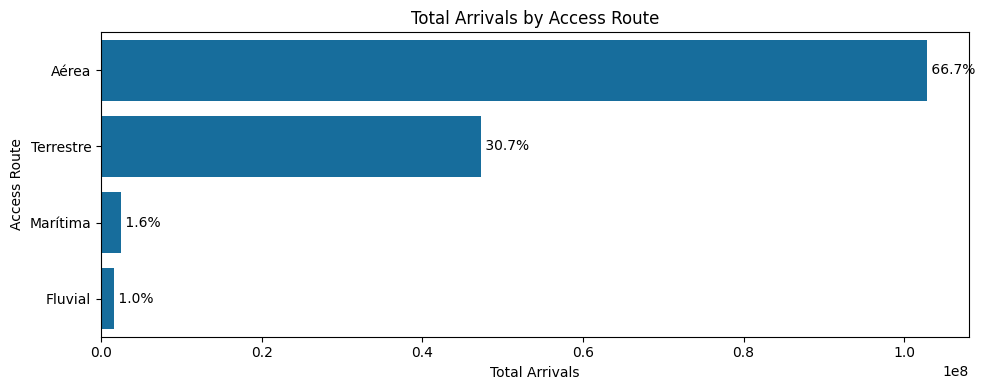

In [4]:
top_access_route = pd.DataFrame(
    df.groupby('access_route')['arrival_count'].sum().nlargest(20)
)
top_access_route['percentage'] = (
    top_access_route['arrival_count'] / top_access_route['arrival_count'].sum()
) * 100

plt.figure(figsize=(10, 4))

sns.barplot(x=top_access_route['arrival_count'], y=top_access_route.index)
plt.title('Total Arrivals by Access Route')
plt.xlabel('Total Arrivals')
plt.ylabel('Access Route')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(top_access_route['arrival_count'], top_access_route['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

plt.tight_layout()

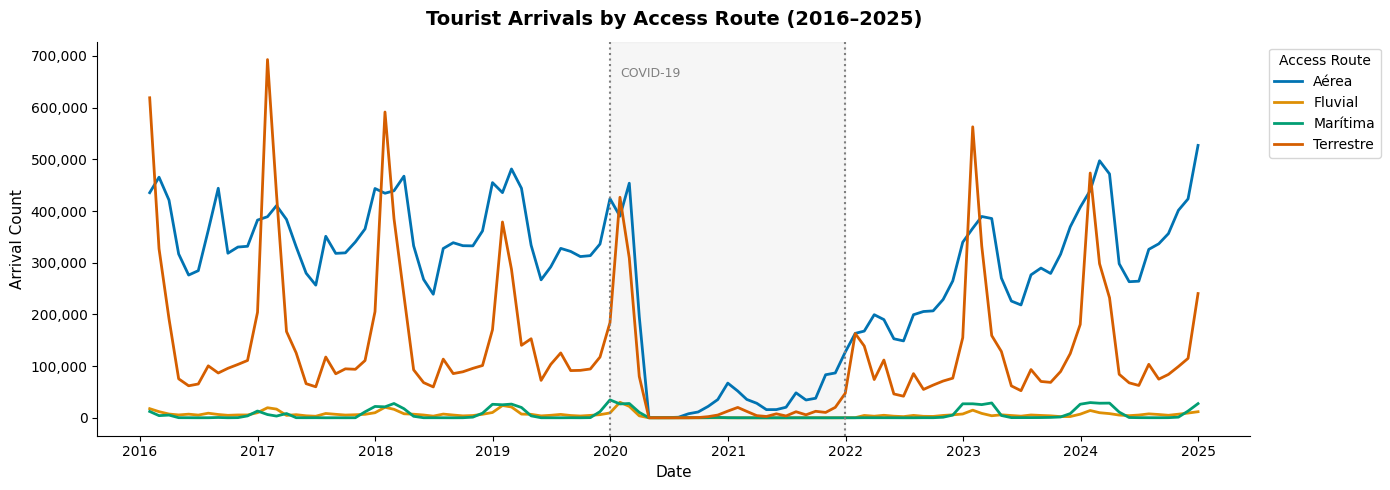

In [5]:
route_time = (
    df[df.index.year >= 2016]
    .groupby(['year_month', 'access_route'], as_index=False)['arrival_count']
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=route_time,
    x='year_month',
    y='arrival_count',
    hue='access_route',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = route_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    'Tourist Arrivals by Access Route (2016–2025)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Arrival Count', fontsize=11)
ax.legend(
    title='Access Route', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

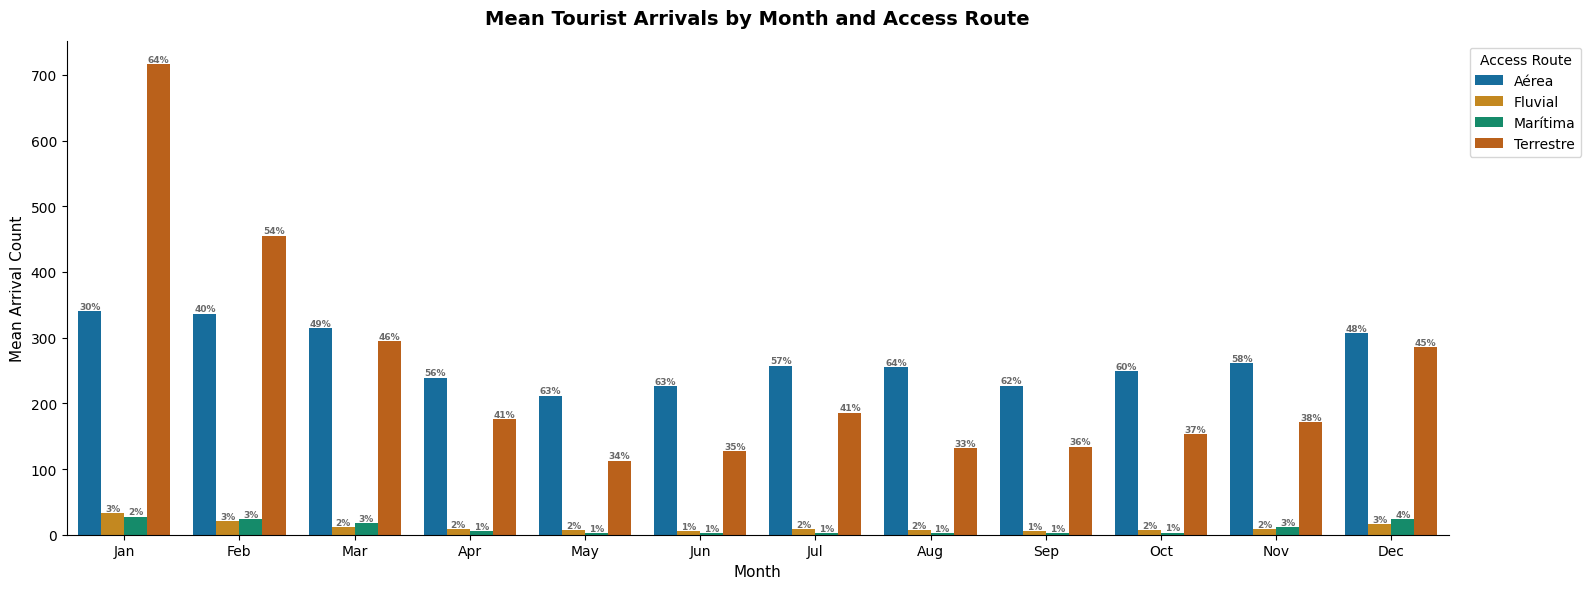

In [6]:
month_route = (
    df.groupby(['month_num', 'access_route'])['arrival_count'].mean().reset_index()
)

month_totals = month_route.groupby('month_num')['arrival_count'].sum()
month_route['pct'] = month_route.apply(
    lambda r: r['arrival_count'] / month_totals[r['month_num']] * 100, axis=1
)

month_labels = [
    'Jan',
    'Feb',
    'Mar',
    'Apr',
    'May',
    'Jun',
    'Jul',
    'Aug',
    'Sep',
    'Oct',
    'Nov',
    'Dec',
]
month_route['month_label'] = (
    month_route['month_num'].astype(int).apply(lambda m: month_labels[m - 1])
)

fig, ax = plt.subplots(figsize=(16, 6))

sns.barplot(
    data=month_route,
    x='month_label',
    y='arrival_count',
    hue='access_route',
    order=month_labels,
    ax=ax,
)

for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        x = bar.get_x() + bar.get_width() / 2
        ax.text(
            x,
            height + 0.5,
            f'{height / month_route["arrival_count"].max() * 100:.0f}%',
            ha='center',
            va='bottom',
            fontsize=6.5,
            color='dimgray',
        )

# re-annotate with actual pct values per bar group
ax.cla()
bar_plot = sns.barplot(
    data=month_route,
    x='month_label',
    y='arrival_count',
    hue='access_route',
    order=month_labels,
    ax=ax,
)

routes = month_route['access_route'].unique()
for month_idx, month in enumerate(month_labels):
    month_data = month_route[month_route['month_label'] == month].set_index(
        'access_route'
    )
    n_routes = len(routes)
    total_width = 0.8
    bar_width = total_width / n_routes
    for route_idx, route in enumerate(routes):
        if route not in month_data.index:
            continue
        row = month_data.loc[route]
        x = month_idx - total_width / 2 + bar_width * route_idx + bar_width / 2
        ax.text(
            x,
            row['arrival_count'] + 0.3,
            f'{row["pct"]:.0f}%',
            ha='center',
            va='bottom',
            fontsize=6.5,
            color='dimgray',
            fontweight='bold',
        )

ax.set_title(
    'Mean Tourist Arrivals by Month and Access Route',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Mean Arrival Count', fontsize=11)
ax.legend(
    title='Access Route', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

### Arrival State and Region

#### Arrival State

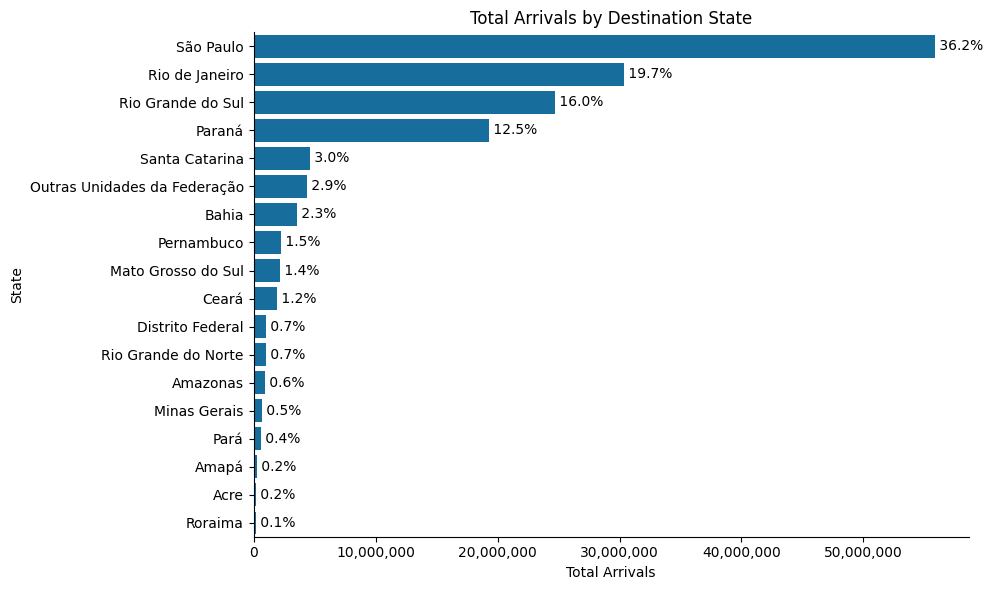

In [7]:
top_states = pd.DataFrame(df.groupby('state')['arrival_count'].sum().nlargest(30))
top_states['percentage'] = (
    top_states['arrival_count'] / top_states['arrival_count'].sum()
) * 100

plt.figure(figsize=(10, 6))

sns.barplot(x=top_states['arrival_count'], y=top_states.index)
plt.title('Total Arrivals by Destination State')
plt.xlabel('Total Arrivals')
plt.ylabel('State')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(top_states['arrival_count'], top_states['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

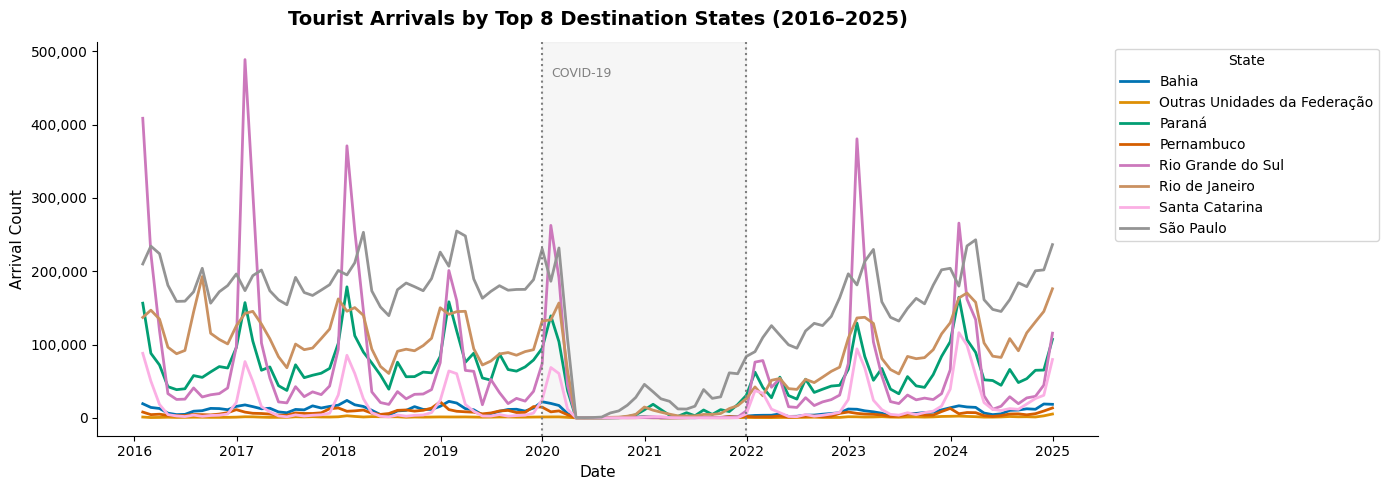

In [8]:
TOP_N = 8
top_state_names = (
    df.groupby('state')['arrival_count'].sum().nlargest(TOP_N).index.tolist()
)

state_time = (
    df[df['state'].isin(top_state_names) & (df.index.year >= 2016)]
    .groupby(['year_month', 'state'], as_index=False)['arrival_count']
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=state_time,
    x='year_month',
    y='arrival_count',
    hue='state',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = state_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    f'Tourist Arrivals by Top {TOP_N} Destination States (2016–2025)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Arrival Count', fontsize=11)
ax.legend(title='State', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

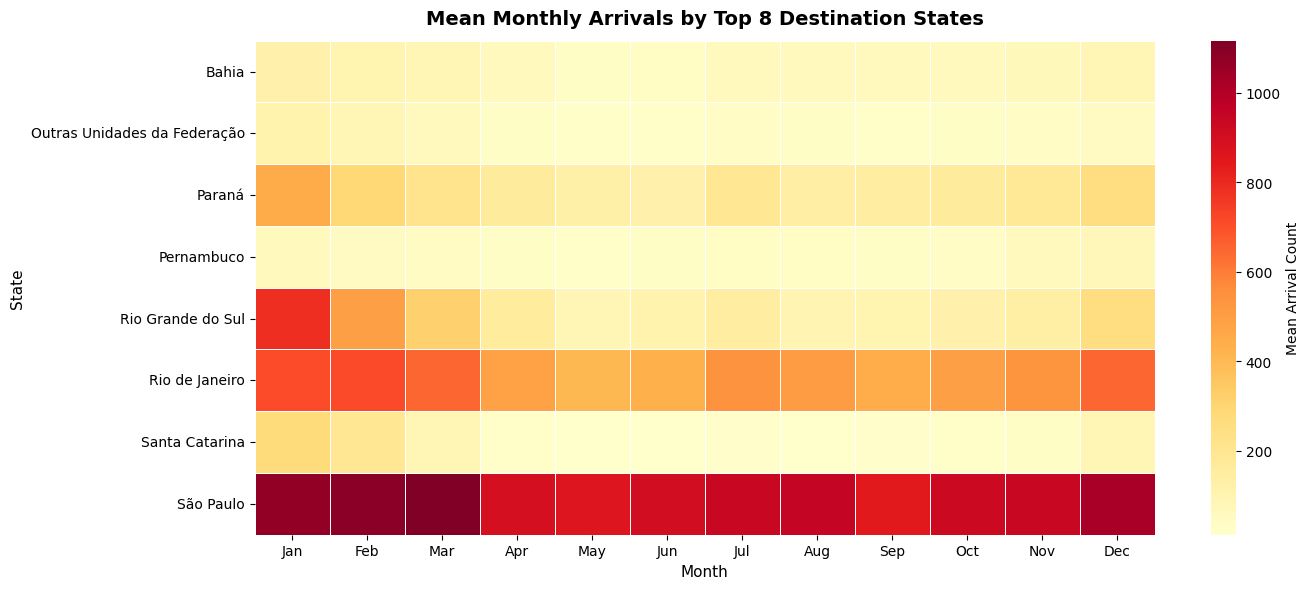

In [9]:
month_labels = [
    'Jan',
    'Feb',
    'Mar',
    'Apr',
    'May',
    'Jun',
    'Jul',
    'Aug',
    'Sep',
    'Oct',
    'Nov',
    'Dec',
]

state_month = (
    df[df['state'].isin(top_state_names)]
    .groupby(['state', 'month_num'])['arrival_count']
    .mean()
    .unstack('month_num')
)
state_month.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    state_month,
    fmt='.0f',
    linewidths=0.4,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Mean Arrival Count'},
)

ax.set_title(
    f'Mean Monthly Arrivals by Top {TOP_N} Destination States',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('State', fontsize=11)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

#### Arrival Region

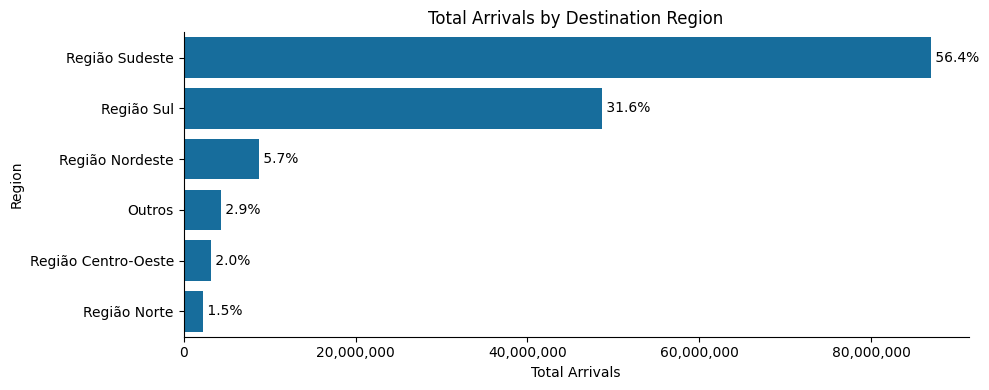

In [10]:
region_totals = pd.DataFrame(
    df.groupby('state_region')['arrival_count'].sum().sort_values(ascending=False)
)
region_totals['percentage'] = (
    region_totals['arrival_count'] / region_totals['arrival_count'].sum()
) * 100

plt.figure(figsize=(10, 4))

sns.barplot(x=region_totals['arrival_count'], y=region_totals.index)
plt.title('Total Arrivals by Destination Region')
plt.xlabel('Total Arrivals')
plt.ylabel('Region')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(region_totals['arrival_count'], region_totals['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

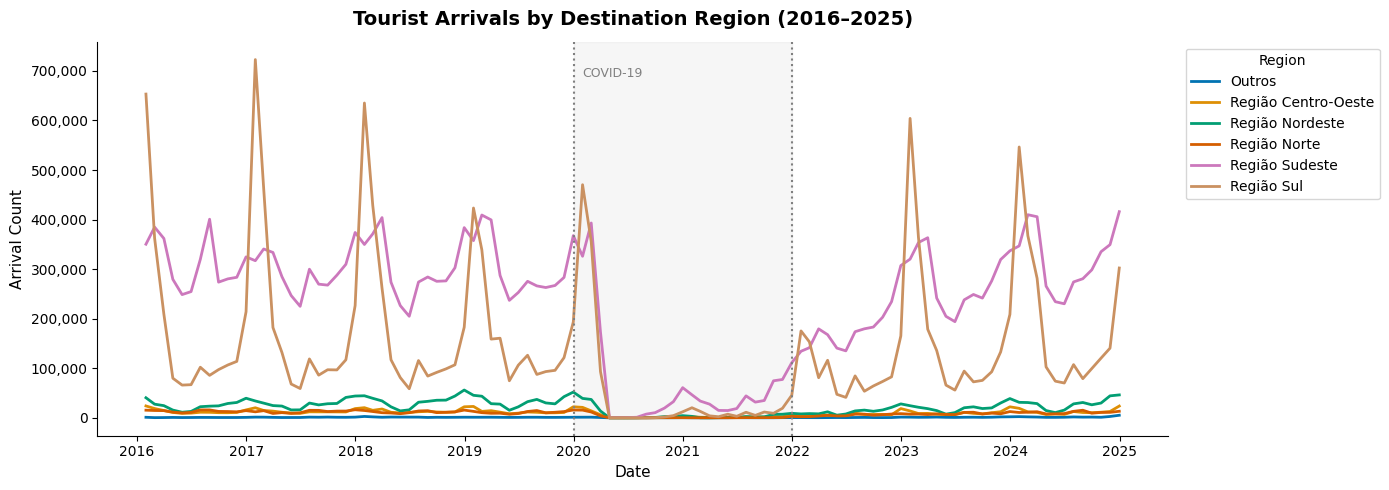

In [11]:
region_time = (
    df[df.index.year >= 2016]
    .groupby(['year_month', 'state_region'], as_index=False)['arrival_count']
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=region_time,
    x='year_month',
    y='arrival_count',
    hue='state_region',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = region_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    'Tourist Arrivals by Destination Region (2016–2025)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Arrival Count', fontsize=11)
ax.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

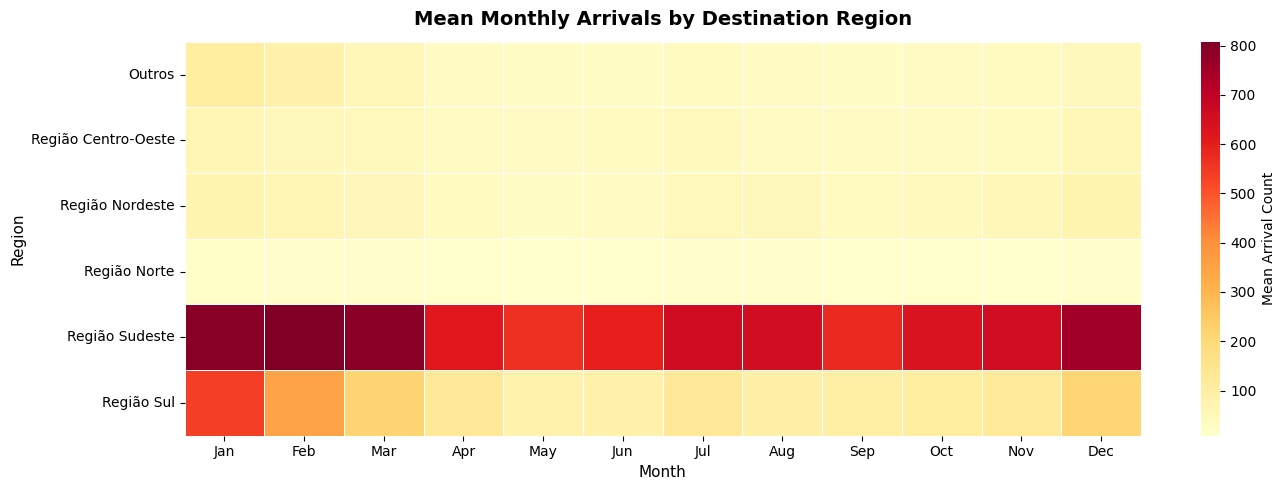

In [12]:
month_labels = [
    'Jan',
    'Feb',
    'Mar',
    'Apr',
    'May',
    'Jun',
    'Jul',
    'Aug',
    'Sep',
    'Oct',
    'Nov',
    'Dec',
]

region_month = (
    df
    .groupby(['state_region', 'month_num'])['arrival_count']
    .mean()
    .unstack('month_num')
)
region_month.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    region_month,
    fmt='.0f',
    linewidths=0.4,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Mean Arrival Count'},
)

ax.set_title(
    'Mean Monthly Arrivals by Destination Region',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Region', fontsize=11)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

### Arrival Country / Cultural Subdivision

#### Origin Country

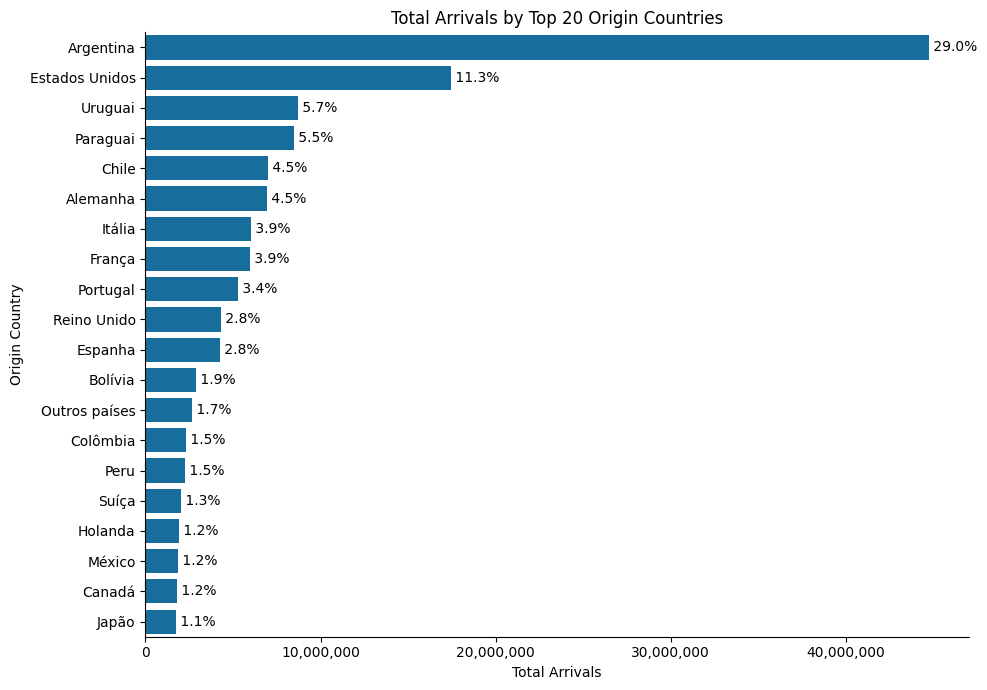

In [13]:
TOP_N_COUNTRIES = 20

top_countries = pd.DataFrame(
    df.groupby('origin_country')['arrival_count'].sum().nlargest(TOP_N_COUNTRIES)
)
top_countries['percentage'] = (
    top_countries['arrival_count']
    / df.groupby('origin_country')['arrival_count'].sum().sum()
) * 100

plt.figure(figsize=(10, 7))

sns.barplot(x=top_countries['arrival_count'], y=top_countries.index)
plt.title(f'Total Arrivals by Top {TOP_N_COUNTRIES} Origin Countries')
plt.xlabel('Total Arrivals')
plt.ylabel('Origin Country')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(top_countries['arrival_count'], top_countries['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

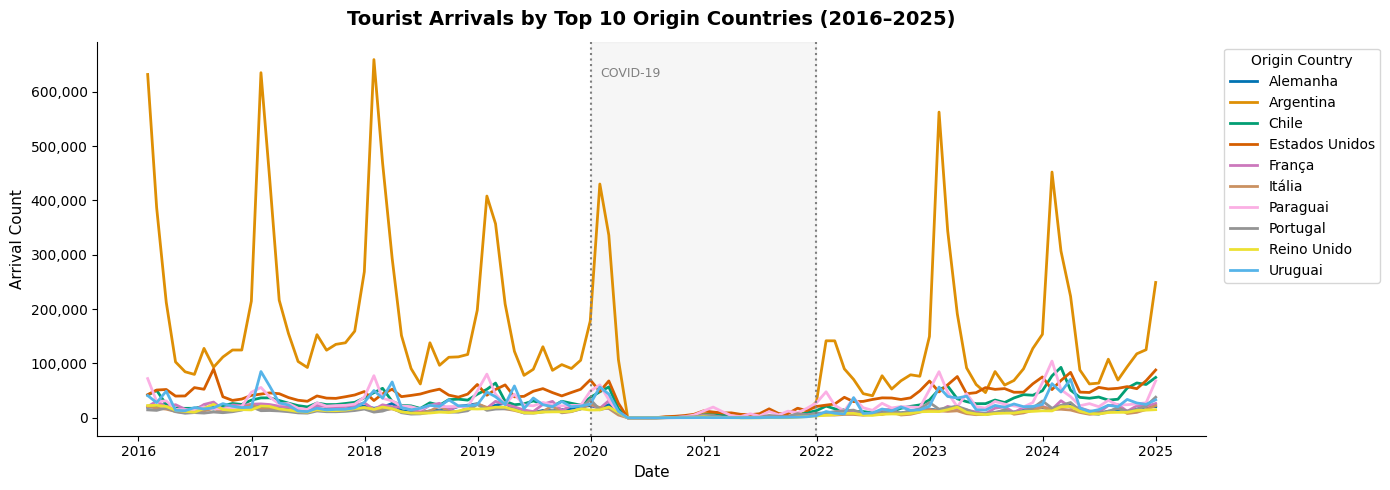

In [14]:
TOP_N_COUNTRIES = 10

top_country_names = (
    df
    .groupby('origin_country')['arrival_count']
    .sum()
    .nlargest(TOP_N_COUNTRIES)
    .index.tolist()
)

country_time = (
    df[df['origin_country'].isin(top_country_names) & (df.index.year >= 2016)]
    .groupby(['year_month', 'origin_country'], as_index=False)['arrival_count']
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=country_time,
    x='year_month',
    y='arrival_count',
    hue='origin_country',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = country_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    f'Tourist Arrivals by Top {TOP_N_COUNTRIES} Origin Countries (2016–2025)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Arrival Count', fontsize=11)
ax.legend(
    title='Origin Country', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

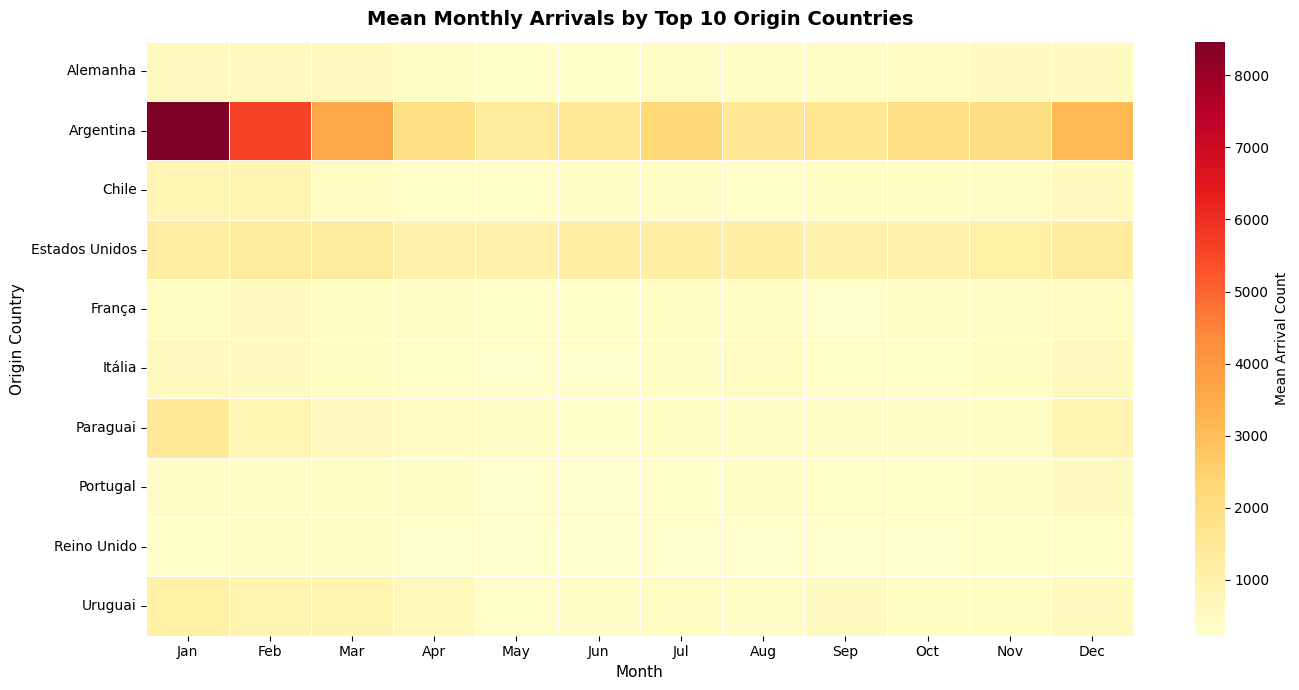

In [15]:
month_labels = [
    'Jan',
    'Feb',
    'Mar',
    'Apr',
    'May',
    'Jun',
    'Jul',
    'Aug',
    'Sep',
    'Oct',
    'Nov',
    'Dec',
]

country_month = (
    df[df['origin_country'].isin(top_country_names)]
    .groupby(['origin_country', 'month_num'])['arrival_count']
    .mean()
    .unstack('month_num')
)
country_month.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    country_month,
    fmt='.0f',
    linewidths=0.4,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Mean Arrival Count'},
)

ax.set_title(
    f'Mean Monthly Arrivals by Top {TOP_N_COUNTRIES} Origin Countries',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Origin Country', fontsize=11)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

#### Cultural Subdivision

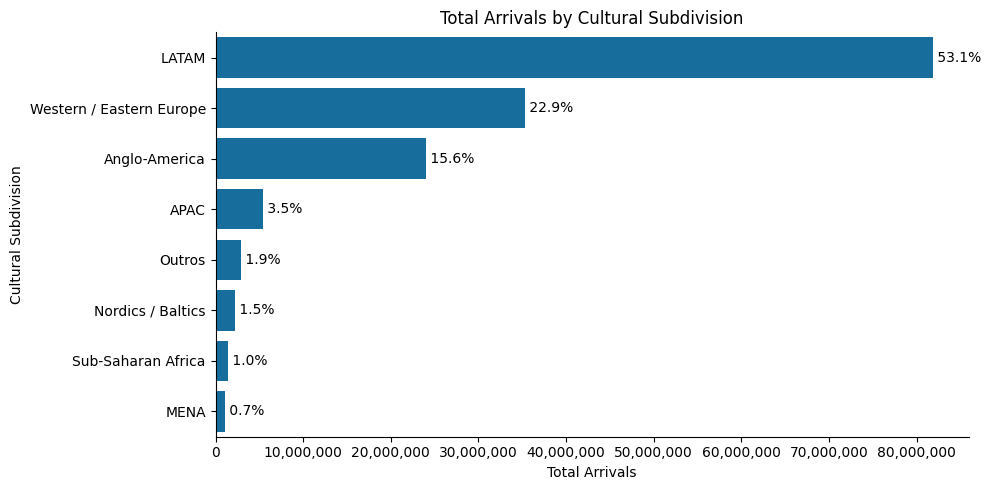

In [16]:
subdivision_totals = pd.DataFrame(
    df
    .groupby('country_cultural_subdivision')['arrival_count']
    .sum()
    .sort_values(ascending=False)
)
subdivision_totals['percentage'] = (
    subdivision_totals['arrival_count'] / subdivision_totals['arrival_count'].sum()
) * 100

plt.figure(figsize=(10, 5))

sns.barplot(x=subdivision_totals['arrival_count'], y=subdivision_totals.index)
plt.title('Total Arrivals by Cultural Subdivision')
plt.xlabel('Total Arrivals')
plt.ylabel('Cultural Subdivision')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(subdivision_totals['arrival_count'], subdivision_totals['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

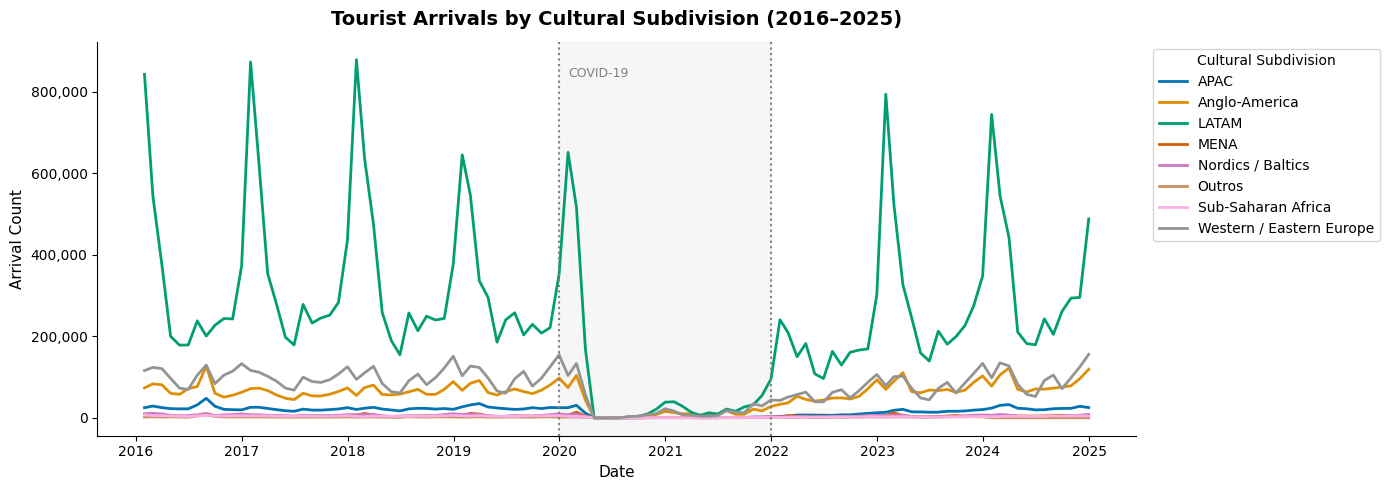

In [17]:
subdivision_time = (
    df[df.index.year >= 2016]
    .groupby(['year_month', 'country_cultural_subdivision'], as_index=False)[
        'arrival_count'
    ]
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=subdivision_time,
    x='year_month',
    y='arrival_count',
    hue='country_cultural_subdivision',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = subdivision_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    'Tourist Arrivals by Cultural Subdivision (2016–2025)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Arrival Count', fontsize=11)
ax.legend(
    title='Cultural Subdivision',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    frameon=True,
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

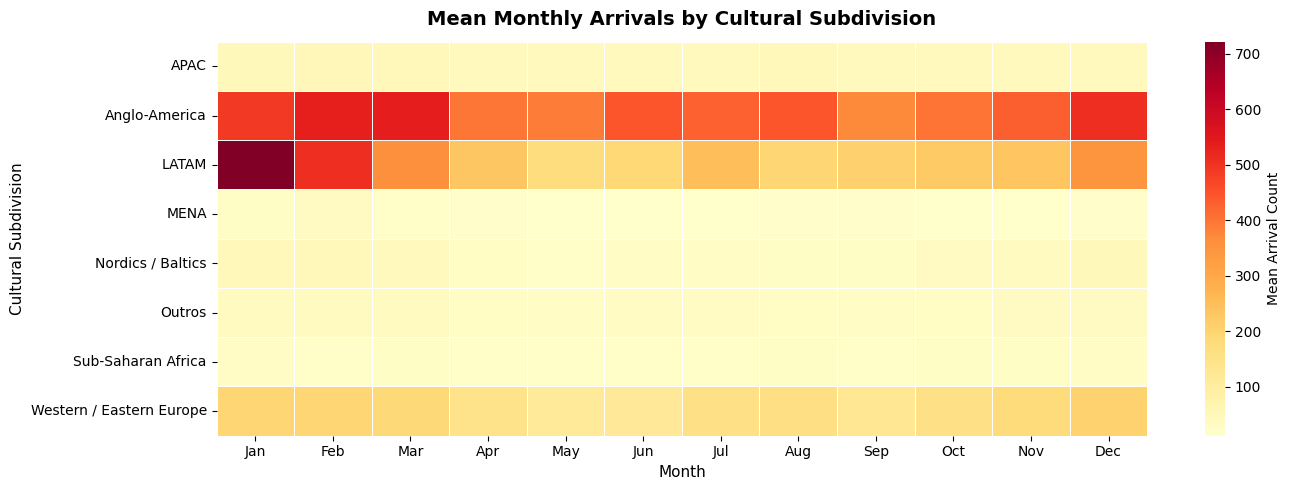

In [18]:
month_labels = [
    'Jan',
    'Feb',
    'Mar',
    'Apr',
    'May',
    'Jun',
    'Jul',
    'Aug',
    'Sep',
    'Oct',
    'Nov',
    'Dec',
]

subdivision_month = (
    df
    .groupby(['country_cultural_subdivision', 'month_num'])['arrival_count']
    .mean()
    .unstack('month_num')
)
subdivision_month.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    subdivision_month,
    fmt='.0f',
    linewidths=0.4,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Mean Arrival Count'},
)

ax.set_title(
    'Mean Monthly Arrivals by Cultural Subdivision',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Cultural Subdivision', fontsize=11)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

## Time Series Analysis

> **Note on transformations.** An earlier version of this section applied `np.log` to the
> series before the additive/multiplicative check, the STL decomposition, the ADF/KPSS
> tests and the ACF/PACF plots. The log was there for two reasons:
>
> 1. **Multiplicative → additive.** The mean–std check shows the seasonal amplitude
>    growing with the level (multiplicative behaviour). STL is additive, so the log was
>    used to turn `trend × season × error` into `trend + season + error`.
> 2. **Variance stabilization.** A log damps the level-dependent variance before running
>    unit-root tests and reading autocorrelations.
>
> The log is the fixed special case λ = 0 of the Box-Cox family, and it was applied
> without first testing whether the variance actually changes with the level, or whether
> λ = 0 is the right strength. The sections below therefore work on the **raw scale**.
> Heteroscedasticity is then tested formally and λ is chosen by **Guerrero's method**
> (see *Heteroscedasticity* and *Box-Cox Transformation*). Results on the raw scale
> should be read with that in mind: the STL seasonal component absorbs the growing
> amplitude, and ADF/KPSS results can be influenced by the changing variance.

#### Oveview

In [19]:
monthly_df = df[['arrival_count']].resample('ME').sum()


def assign_period(date):
    if date < pd.Timestamp('2000-01-01'):
        return 'Legacy (< 2000)'
    elif date < COVID_START:
        return 'Pre-Pandemic (2000–2019)'
    elif date <= COVID_END:
        return 'Pandemic (2020–2021)'
    else:
        return 'Post-Pandemic (2022+)'


monthly_df['period'] = monthly_df.index.map(assign_period)
monthly_df.head()

,arrival_count,period
date,,
1989-01-31,291566.0,Legacy (< 2000)
1989-02-28,197348.0,Legacy (< 2000)
1989-03-31,149001.0,Legacy (< 2000)
1989-04-30,84867.0,Legacy (< 2000)
1989-05-31,69293.0,Legacy (< 2000)


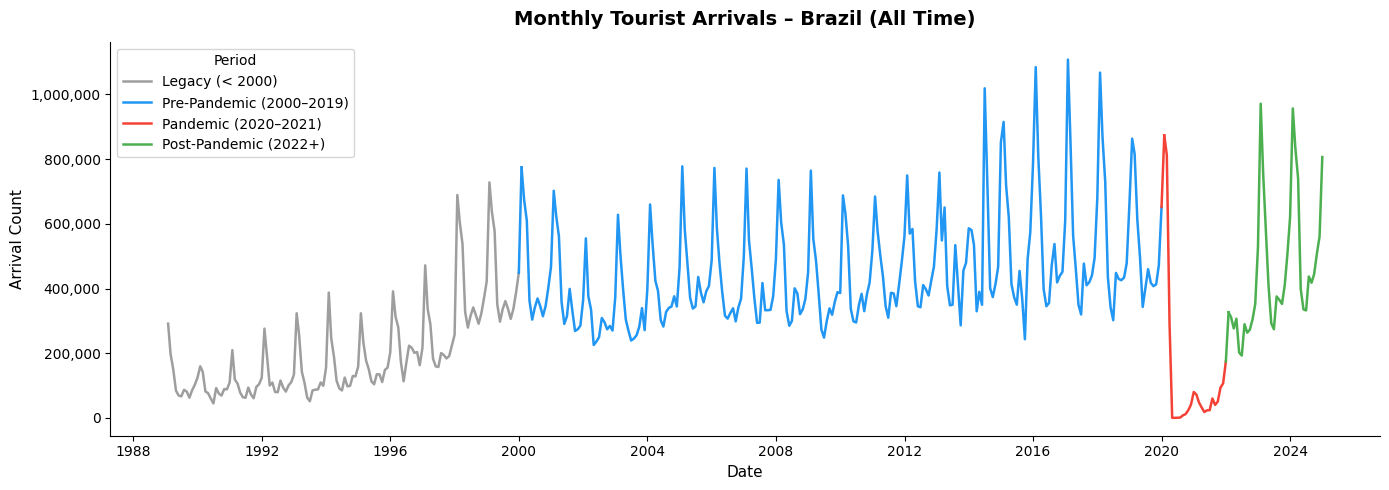

In [20]:
period_colors = {
    'Legacy (< 2000)': '#9e9e9e',
    'Pre-Pandemic (2000–2019)': '#2196f3',
    'Pandemic (2020–2021)': '#f44336',
    'Post-Pandemic (2022+)': '#4caf50',
}

fig, ax = plt.subplots(figsize=(14, 5))

for period, color in period_colors.items():
    segment = monthly_df[monthly_df['period'] == period]
    if segment.empty:
        continue
    ax.plot(
        segment.index,
        segment['arrival_count'],
        color=color,
        linewidth=1.8,
        label=period,
    )

# stitch consecutive segments so there are no visual gaps at boundaries
for i in range(len(monthly_df) - 1):
    curr, nxt = monthly_df.iloc[i], monthly_df.iloc[i + 1]
    if curr['period'] != nxt['period']:
        ax.plot(
            [monthly_df.index[i], monthly_df.index[i + 1]],
            [curr['arrival_count'], nxt['arrival_count']],
            color=period_colors[nxt['period']],
            linewidth=1.8,
        )

ax.set_title(
    'Monthly Tourist Arrivals – Brazil (All Time)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Arrival Count', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Period', frameon=True)
sns.despine()
plt.tight_layout()

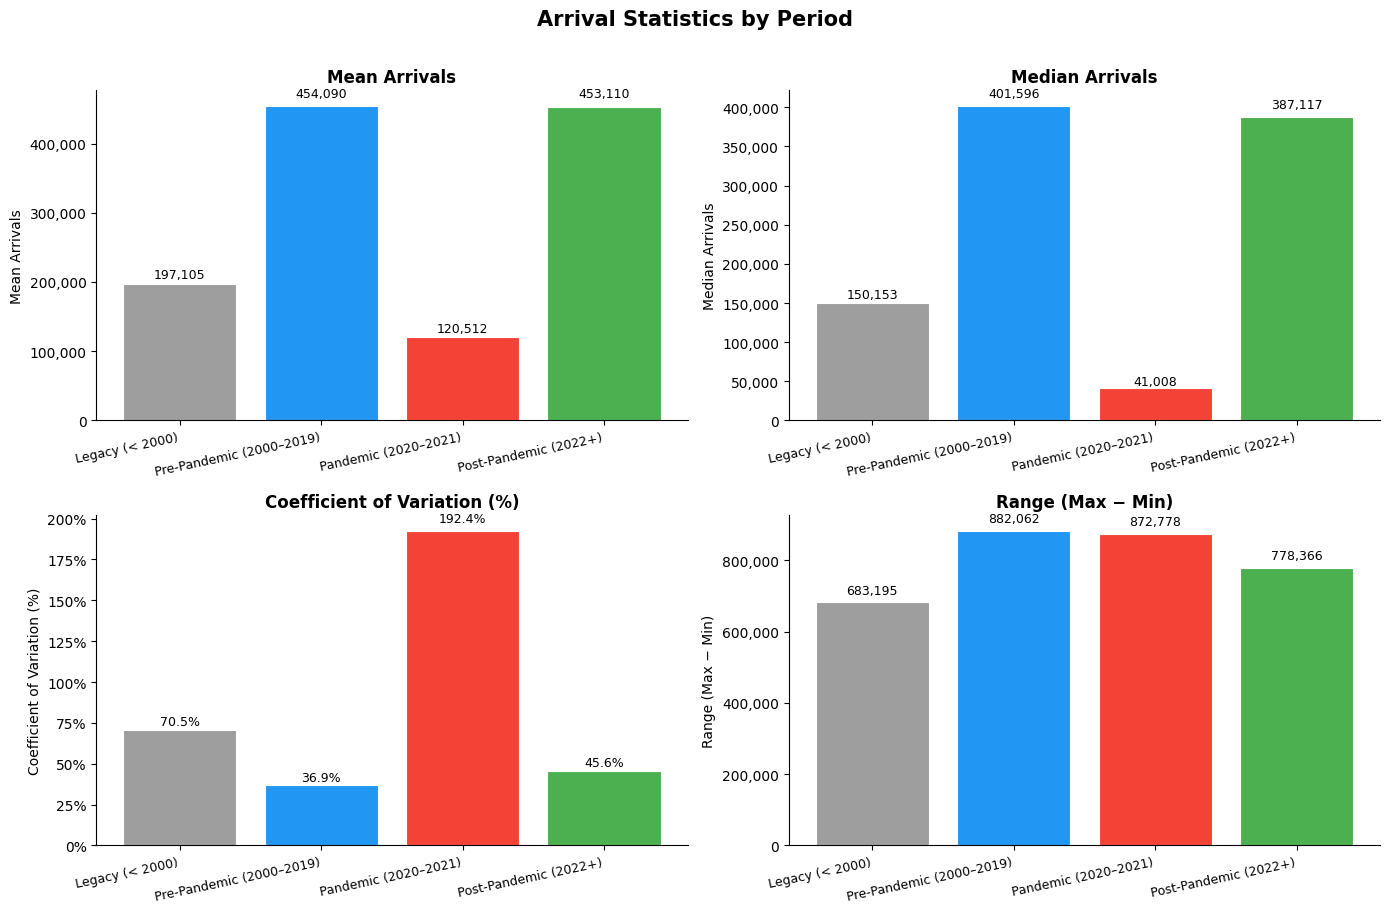

In [21]:
period_order = [
    'Legacy (< 2000)',
    'Pre-Pandemic (2000–2019)',
    'Pandemic (2020–2021)',
    'Post-Pandemic (2022+)',
]
period_colors_list = [period_colors[p] for p in period_order]

period_stats = (
    monthly_df
    .groupby('period')['arrival_count']
    .agg(
        mean='mean',
        median='median',
        cv=lambda x: x.std() / x.mean() * 100,
        range=lambda x: x.max() - x.min(),
    )
    .reindex(period_order)
)

metrics = [
    ('mean', 'Mean Arrivals', lambda v: f'{int(v):,}'),
    ('median', 'Median Arrivals', lambda v: f'{int(v):,}'),
    ('cv', 'Coefficient of Variation (%)', lambda v: f'{v:.1f}%'),
    ('range', 'Range (Max − Min)', lambda v: f'{int(v):,}'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Arrival Statistics by Period', fontsize=15, fontweight='bold', y=1.01)

for ax, (col, title, fmt) in zip(axes.flat, metrics):
    bars = ax.bar(
        range(len(period_order)),
        period_stats[col],
        color=period_colors_list,
        edgecolor='white',
        linewidth=0.8,
    )
    for bar, val in zip(bars, period_stats[col]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            fmt(val),
            ha='center',
            va='bottom',
            fontsize=9,
        )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(title, fontsize=10)
    ax.set_xticks(range(len(period_order)))
    ax.set_xticklabels(period_order, rotation=12, ha='right', fontsize=9)
    is_cv = col == 'cv'
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda x, _, _is_cv=is_cv: f'{x:.0f}%' if _is_cv else f'{x:,.0f}'
        )
    )
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

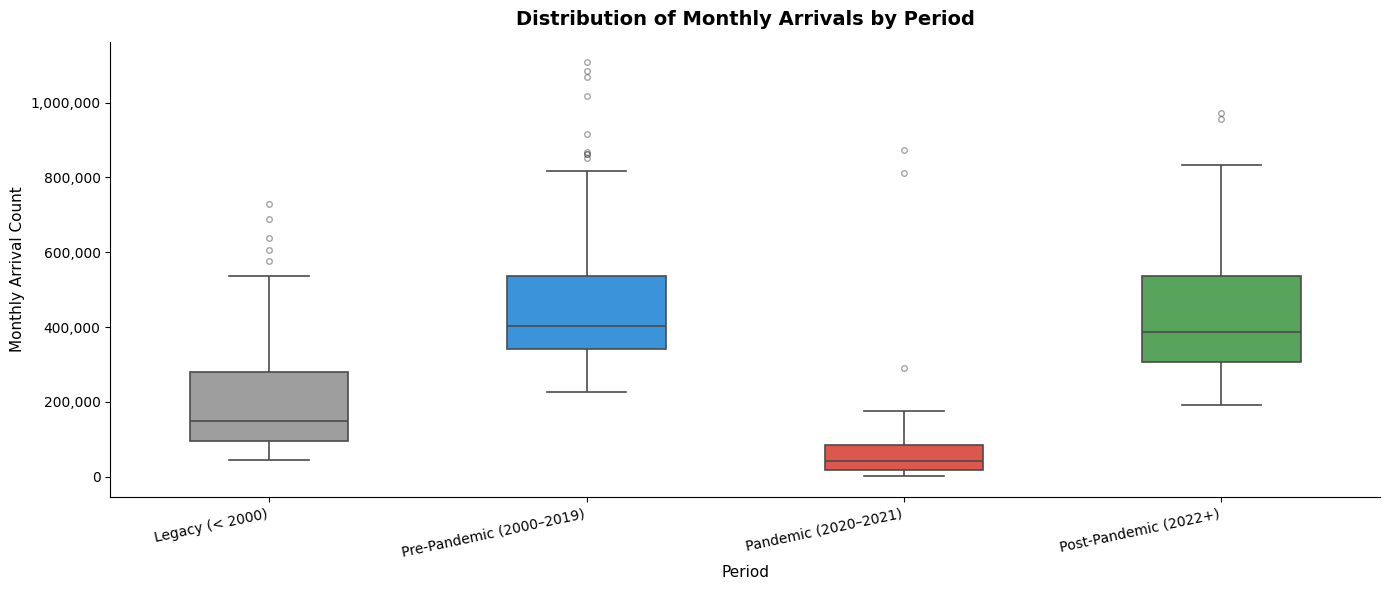

In [22]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=monthly_df,
    x='period',
    y='arrival_count',
    hue='period',
    order=period_order,
    palette=period_colors,
    width=0.5,
    linewidth=1.2,
    flierprops=dict(marker='o', markersize=4, alpha=0.5),
    legend=False,
    ax=ax,
)

ax.set_title(
    'Distribution of Monthly Arrivals by Period', fontsize=14, fontweight='bold', pad=12
)
ax.set_xlabel('Period', fontsize=11)
ax.set_ylabel('Monthly Arrival Count', fontsize=11)
ax.set_xticks(range(len(period_order)))
ax.set_xticklabels(period_order, rotation=12, ha='right', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
plt.show()

#### Trend

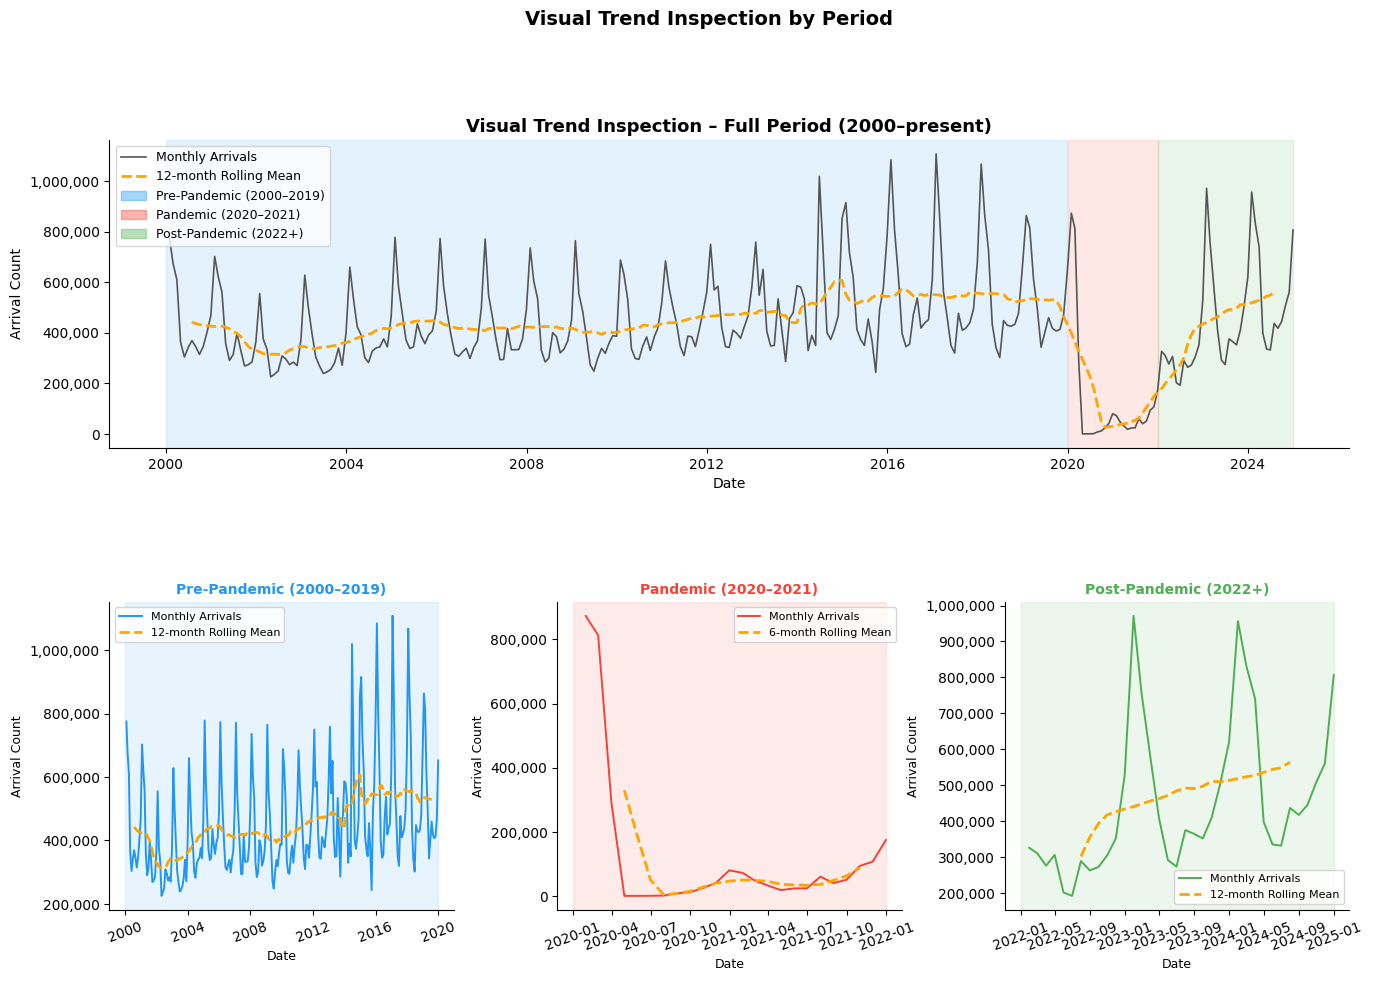

In [23]:
import matplotlib.patches as mpatches

trend_periods = [
    (
        'Pre-Pandemic (2000–2019)',
        pd.Timestamp('2000-01-01'),
        pd.Timestamp('2019-12-31'),
    ),
    ('Pandemic (2020–2021)', COVID_START, COVID_END),
    ('Post-Pandemic (2022+)', pd.Timestamp('2022-01-01'), monthly_df.index[-1]),
]

post_2000 = monthly_df[monthly_df['period'] != 'Legacy (< 2000)']

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.3)

# ── top: full post-2000 spanning all 3 columns ────────────────────────────────
ax_full = fig.add_subplot(gs[0, :])

ax_full.plot(
    post_2000.index,
    post_2000['arrival_count'],
    color='#555555',
    linewidth=1.2,
    label='Monthly Arrivals',
)

rolling_full = post_2000['arrival_count'].rolling(12, center=True).mean()
ax_full.plot(
    post_2000.index,
    rolling_full,
    color='orange',
    linewidth=2,
    linestyle='--',
    label='12-month Rolling Mean',
)

for period, start, end in trend_periods:
    ax_full.axvspan(start, end, alpha=0.12, color=period_colors[period])

line_handles, _ = ax_full.get_legend_handles_labels()
span_handles = [
    mpatches.Patch(color=period_colors[p], alpha=0.4, label=p)
    for p, _, _ in trend_periods
]
ax_full.legend(handles=line_handles + span_handles, fontsize=9, frameon=True)
ax_full.set_title(
    'Visual Trend Inspection – Full Period (2000–present)',
    fontsize=13,
    fontweight='bold',
)
ax_full.set_xlabel('Date', fontsize=10)
ax_full.set_ylabel('Arrival Count', fontsize=10)
ax_full.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine(ax=ax_full)

# ── bottom: one subplot per period ───────────────────────────────────────────
for col_idx, (period, start, end) in enumerate(trend_periods):
    ax = fig.add_subplot(gs[1, col_idx])
    color = period_colors[period]

    segment = monthly_df[(monthly_df.index >= start) & (monthly_df.index <= end)]

    ax.plot(
        segment.index,
        segment['arrival_count'],
        color=color,
        linewidth=1.4,
        label='Monthly Arrivals',
    )
    ax.axvspan(start, end, alpha=0.1, color=color)

    # pandemic (~24 obs) is too short for a 12-month centered window
    window = 6 if len(segment) < 36 else 12
    rolling = segment['arrival_count'].rolling(window, center=True).mean()
    ax.plot(
        segment.index,
        rolling,
        color='orange',
        linewidth=2,
        linestyle='--',
        label=f'{window}-month Rolling Mean',
    )

    ax.set_title(period, fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Arrival Count', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=8, frameon=True)
    ax.tick_params(axis='x', rotation=20)
    sns.despine(ax=ax)

plt.suptitle(
    'Visual Trend Inspection by Period', fontsize=14, fontweight='bold', y=1.01
)
plt.show()

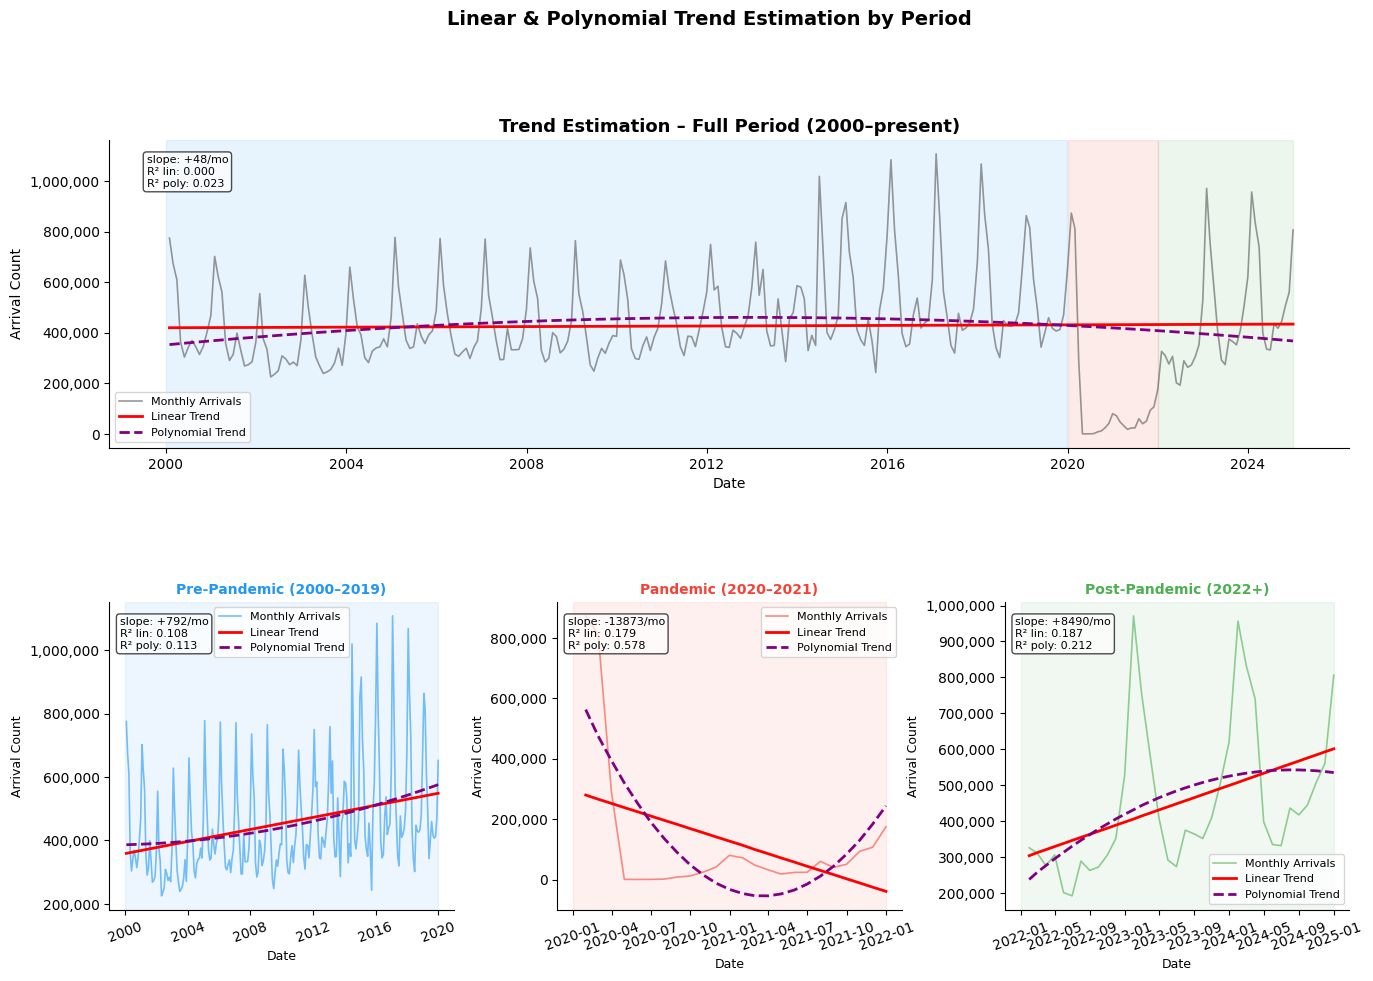

                           Linear Slope (arrivals/month) R² Linear R² Polynomial
Period                                                                          
Full Period (2000–present)                         +48.0    0.0004        0.0233
Pre-Pandemic (2000–2019)                          +791.8    0.1079        0.1133
Pandemic (2020–2021)                            -13872.5    0.1790        0.5778
Post-Pandemic (2022+)                            +8489.8    0.1870        0.2118


In [24]:
def fit_trends(series):
    """Return (lin_model, poly_model, poly_features, t_index, stats_dict)."""
    t = np.arange(len(series)).reshape(-1, 1)
    y = series.values

    lin = LinearRegression().fit(t, y)

    pf = PolynomialFeatures(degree=2)
    poly = LinearRegression().fit(pf.fit_transform(t), y)

    stats = {
        'slope': lin.coef_[0],
        'r2_lin': lin.score(t, y),
        'r2_poly': poly.score(pf.fit_transform(t), y),
    }
    return lin, poly, pf, t, stats


def plot_trend_panel(ax, segment, period, color):
    lin, poly, pf, t, stats = fit_trends(segment['arrival_count'])

    ax.plot(
        segment.index,
        segment['arrival_count'],
        color=color,
        linewidth=1.2,
        alpha=0.6,
        label='Monthly Arrivals',
    )
    ax.plot(
        segment.index, lin.predict(t), color='red', linewidth=2, label='Linear Trend'
    )
    ax.plot(
        segment.index,
        poly.predict(pf.fit_transform(t)),
        color='purple',
        linewidth=2,
        linestyle='--',
        label='Polynomial Trend',
    )

    ax.annotate(
        f'slope: {stats["slope"]:+.0f}/mo\nR² lin: {stats["r2_lin"]:.3f}\nR² poly: {stats["r2_poly"]:.3f}',
        xy=(0.03, 0.95),
        xycoords='axes fraction',
        va='top',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7),
    )
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=8, frameon=True)
    sns.despine(ax=ax)
    return stats


# ── build figure ─────────────────────────────────────────────────────────────
post_2000 = monthly_df[monthly_df['period'] != 'Legacy (< 2000)']

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.3)

# top: full post-2000
ax_full = fig.add_subplot(gs[0, :])
full_stats = plot_trend_panel(ax_full, post_2000, 'Full Period', '#555555')

for period, start, end in trend_periods:
    ax_full.axvspan(start, end, alpha=0.1, color=period_colors[period])

ax_full.set_title(
    'Trend Estimation – Full Period (2000–present)', fontsize=13, fontweight='bold'
)
ax_full.set_xlabel('Date', fontsize=10)
ax_full.set_ylabel('Arrival Count', fontsize=10)

# bottom: one per period
all_stats = [('Full Period (2000–present)', full_stats)]

for col_idx, (period, start, end) in enumerate(trend_periods):
    ax = fig.add_subplot(gs[1, col_idx])
    color = period_colors[period]

    segment = monthly_df[(monthly_df.index >= start) & (monthly_df.index <= end)]
    stats = plot_trend_panel(ax, segment, period, color)
    ax.axvspan(start, end, alpha=0.08, color=color)
    ax.set_title(period, fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Arrival Count', fontsize=9)
    ax.tick_params(axis='x', rotation=20)

    all_stats.append((period, stats))

plt.suptitle(
    'Linear & Polynomial Trend Estimation by Period',
    fontsize=14,
    fontweight='bold',
    y=1.01,
)
plt.show()

# ── summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame(
    [
        (p, f'{s["slope"]:+.1f}', f'{s["r2_lin"]:.4f}', f'{s["r2_poly"]:.4f}')
        for p, s in all_stats
    ],
    columns=['Period', 'Linear Slope (arrivals/month)', 'R² Linear', 'R² Polynomial'],
).set_index('Period')

print(summary.to_string())

##### Statistical Trend Tests

The visual and regression checks above are complemented with the non-parametric tests
wrapped by `check_trend` and `check_deterministic_trend` (Joseph & Tackes, *Modern Time
Series Forecasting with Python* 2E, `src/transforms/stationary_utils.py`):

- **Kendall's τ**: rank correlation between the series and time.
- **Mann-Kendall**: monotonic-trend test with Sen's slope. For series with fewer than 50
  points the helper applies the pre-whitening variant to reduce the effect of
  autocorrelation.
- **Seasonal Mann-Kendall (m = 12)**: runs the test within each calendar month, so the
  seasonal cycle does not hide or inflate the trend. The slope is in arrivals per year.
- **Deterministic trend**: ADF with constant only (`c`) vs constant + trend (`ct`). If the
  series is non-stationary under `c` but stationary under `ct`, the trend is deterministic
  and detrending is enough. Otherwise differencing is needed.

In [26]:
# Helpers `check_trend` / `check_deterministic_trend` from Joseph & Tackes,
# "Modern Time Series Forecasting with Python" 2E — src/transforms/stationary_utils.py

period_series = {
    'Full Period (2000–present)': post_2000['arrival_count'],
    **{
        period: monthly_df.loc[
            (monthly_df.index >= start) & (monthly_df.index <= end), 'arrival_count'
        ]
        for period, start, end in trend_periods
    },
}
period_series_colors = {
    'Full Period (2000–present)': '#555555',
    **{p: period_colors[p] for p, _, _ in trend_periods},
}

trend_rows = []
for label, series in period_series.items():
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kt = check_trend(series, confidence=0.05)
        mk_res = check_trend(series, confidence=0.05, mann_kendall=True)
        smk = check_trend(
            series, confidence=0.05, mann_kendall=True, seasonal_period=SEASONAL_PERIOD
        )
        det = check_deterministic_trend(series, confidence=0.05)

    trend_rows.append({
        'Period': label,
        'n': len(series),
        'Kendall τ': f'{kt.slope:+.3f}',
        'Kendall p': f'{kt.p_value:.4f}',
        'Kendall trend': '✓' if kt.trend else '✗',
        'MK test': type(mk_res).__name__.replace('_', ' '),
        "MK Sen's slope (/mo)": f'{mk_res.slope:+,.0f}',
        'MK p': f'{mk_res.p_value:.4f}',
        'MK trend': '✓' if mk_res.trend else '✗',
        'Seasonal MK slope (/yr)': f'{smk.slope:+,.0f}',
        'Seasonal MK p': f'{smk.p_value:.4f}',
        'Seasonal MK trend': '✓' if smk.trend else '✗',
        'ADF(c) p': f'{det.adf_res.results[1]:.4f}',
        'ADF(ct) p': f'{det.adf_ct_res.results[1]:.4f}',
        'Deterministic trend': '✓' if det.deterministic_trend else '✗',
    })

trend_tests = pd.DataFrame(trend_rows).set_index('Period')

print('=' * 100)
print('TREND TESTS — Kendall τ, Mann-Kendall, Seasonal MK (m=12), ADF c vs ct')
print('H0 (Kendall / MK): no monotonic trend → reject (p < 0.05) = trend present')
print('=' * 100)
print(trend_tests.T.to_string())

TREND TESTS — Kendall τ, Mann-Kendall, Seasonal MK (m=12), ADF c vs ct
H0 (Kendall / MK): no monotonic trend → reject (p < 0.05) = trend present
Period                  Full Period (2000–present) Pre-Pandemic (2000–2019)                              Pandemic (2020–2021)                             Post-Pandemic (2022+)
n                                              300                      240                                                24                                                36
Kendall τ                                   +0.069                   +0.263                                            +0.261                                            +0.410
Kendall p                                   0.0757                   0.0000                                            0.0781                                            0.0004
Kendall trend                                    ✗                        ✓                                                 ✗                          

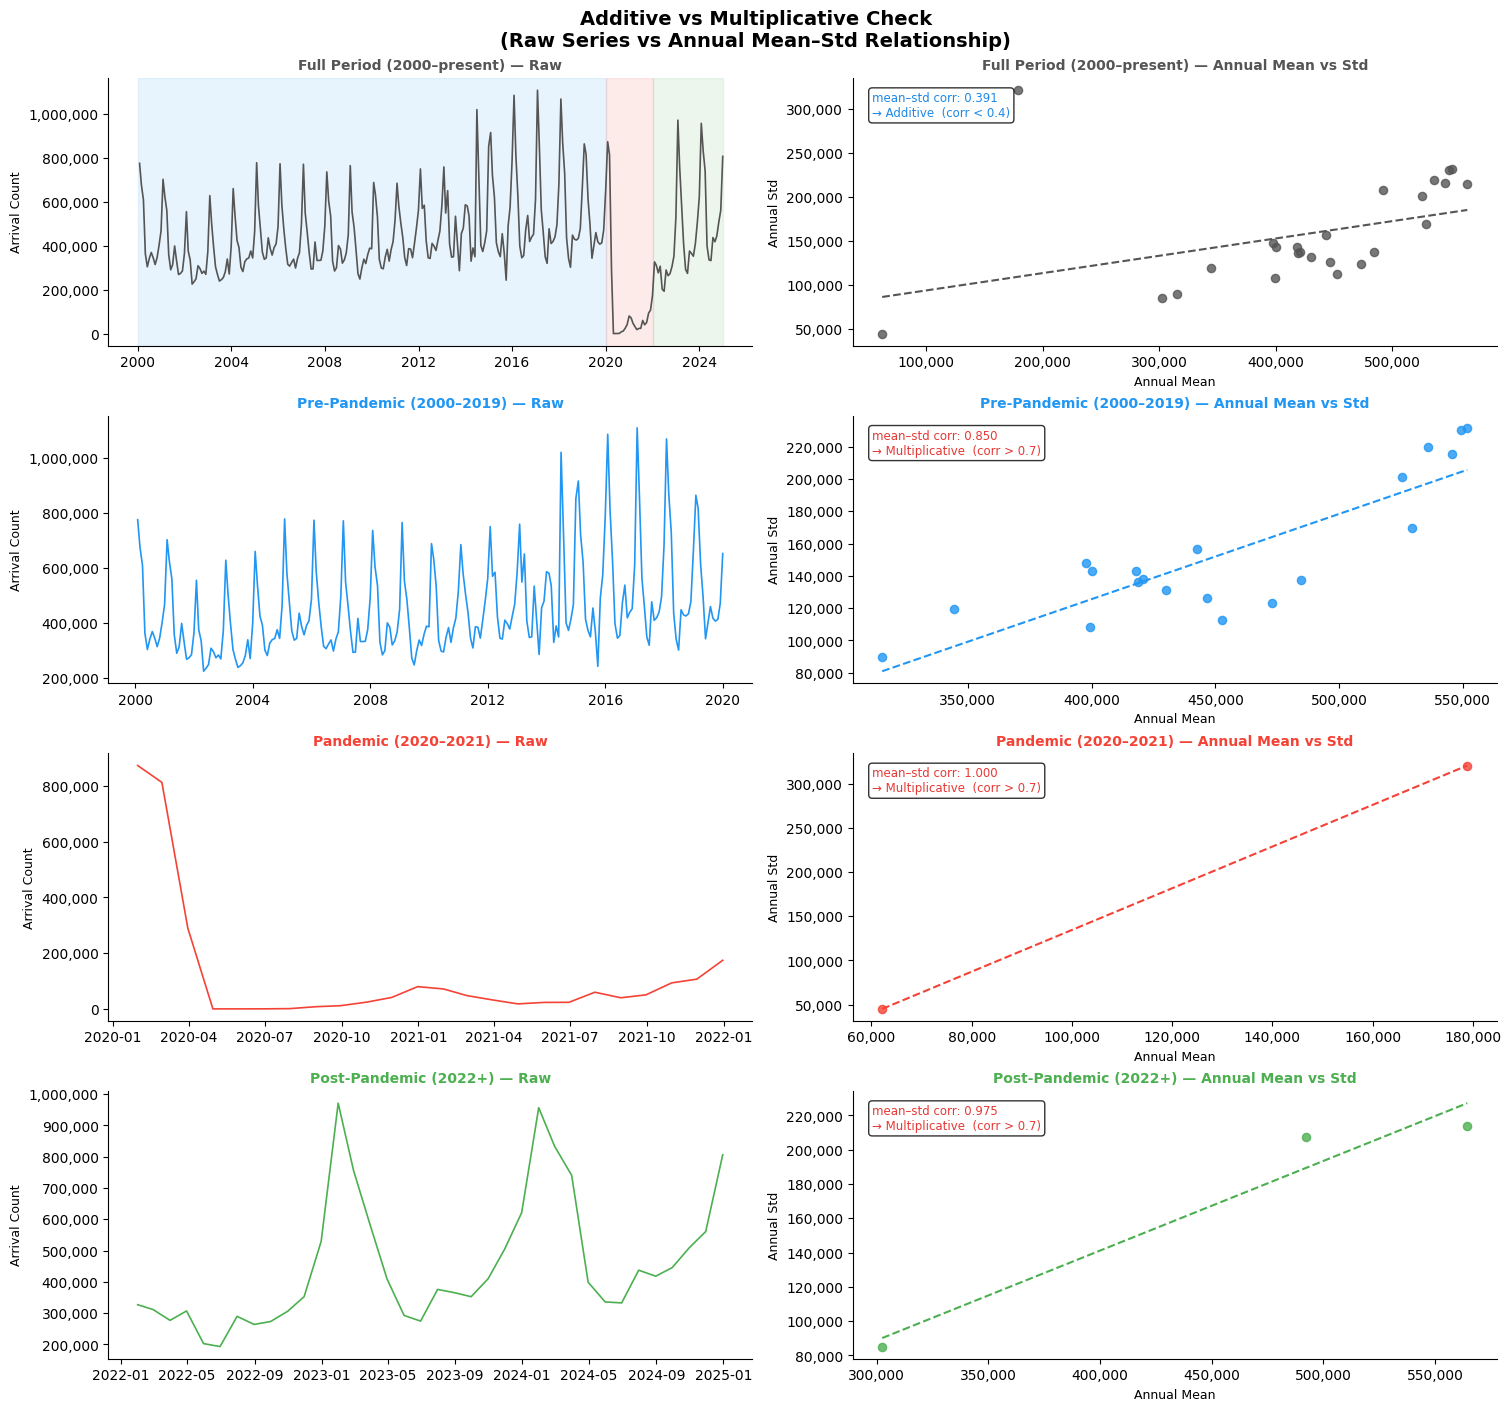

                           Mean–Std Correlation                       Verdict
Period                                                                       
Full Period (2000–present)                0.391        Additive  (corr < 0.4)
Pre-Pandemic (2000–2019)                  0.850  Multiplicative  (corr > 0.7)
Pandemic (2020–2021)                      1.000  Multiplicative  (corr > 0.7)
Post-Pandemic (2022+)                     0.975  Multiplicative  (corr > 0.7)


In [27]:
def additive_or_multiplicative(segment, label, color):
    """Visual + quantitative check for decomposition type."""
    series = segment['arrival_count'].dropna()

    annual = series.resample('YE').agg(['mean', 'std']).dropna()
    corr = annual['mean'].corr(annual['std'])

    if corr > 0.7:
        verdict = 'Multiplicative  (corr > 0.7)'
        verdict_color = '#e53935'
    elif corr < 0.4:
        verdict = 'Additive  (corr < 0.4)'
        verdict_color = '#1e88e5'
    else:
        verdict = 'Ambiguous  (0.4 ≤ corr ≤ 0.7)'
        verdict_color = '#fb8c00'

    return {
        'label': label,
        'corr': corr,
        'verdict': verdict,
        'verdict_color': verdict_color,
        'series': series,
        'annual': annual,
        'color': color,
    }


non_legacy_periods = [
    (
        'Pre-Pandemic (2000–2019)',
        pd.Timestamp('2000-01-01'),
        pd.Timestamp('2019-12-31'),
    ),
    ('Pandemic (2020–2021)', COVID_START, COVID_END),
    ('Post-Pandemic (2022+)', pd.Timestamp('2022-01-01'), monthly_df.index[-1]),
]

post_2000 = monthly_df[monthly_df['period'] != 'Legacy (< 2000)']

results = [
    additive_or_multiplicative(post_2000, 'Full Period (2000–present)', '#555555')
]
for period, start, end in non_legacy_periods:
    seg = monthly_df[(monthly_df.index >= start) & (monthly_df.index <= end)]
    results.append(additive_or_multiplicative(seg, period, period_colors[period]))

# ── 4 × 2 figure: raw series vs annual mean–std relationship ─────────────────
fig, axes = plt.subplots(4, 2, figsize=(15, 14), constrained_layout=True)
fig.suptitle(
    'Additive vs Multiplicative Check\n(Raw Series vs Annual Mean–Std Relationship)',
    fontsize=14,
    fontweight='bold',
)

for row, res in enumerate(results):
    ax_raw, ax_ms = axes[row, 0], axes[row, 1]
    color = res['color']

    ax_raw.plot(res['series'].index, res['series'], color=color, linewidth=1.2)
    ax_raw.set_title(
        f'{res["label"]} — Raw', fontsize=10, fontweight='bold', color=color
    )
    ax_raw.set_ylabel('Arrival Count', fontsize=9)
    ax_raw.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(ax=ax_raw)

    annual = res['annual']
    ax_ms.scatter(annual['mean'], annual['std'], color=color, s=35, alpha=0.8)
    if len(annual) > 1:
        coef = np.polyfit(annual['mean'], annual['std'], 1)
        x_line = np.linspace(annual['mean'].min(), annual['mean'].max(), 50)
        ax_ms.plot(x_line, np.polyval(coef, x_line), color=color, linestyle='--')
    ax_ms.set_title(
        f'{res["label"]} — Annual Mean vs Std',
        fontsize=10,
        fontweight='bold',
        color=color,
    )
    ax_ms.set_xlabel('Annual Mean', fontsize=9)
    ax_ms.set_ylabel('Annual Std', fontsize=9)
    ax_ms.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax_ms.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax_ms.annotate(
        f'mean–std corr: {res["corr"]:.3f}\n→ {res["verdict"]}',
        xy=(0.03, 0.95),
        xycoords='axes fraction',
        va='top',
        fontsize=8.5,
        color=res['verdict_color'],
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8),
    )
    sns.despine(ax=ax_ms)

    # period shading on full-period row only
    if res['label'] == 'Full Period (2000–present)':
        for period, start, end in non_legacy_periods:
            ax_raw.axvspan(start, end, alpha=0.1, color=period_colors[period])

plt.show()

# ── summary table ─────────────────────────────────────────────────────────────
summary_add = pd.DataFrame(
    [(r['label'], f'{r["corr"]:.3f}', r['verdict']) for r in results],
    columns=['Period', 'Mean–Std Correlation', 'Verdict'],
).set_index('Period')

print(summary_add.to_string())

#### Seasonal

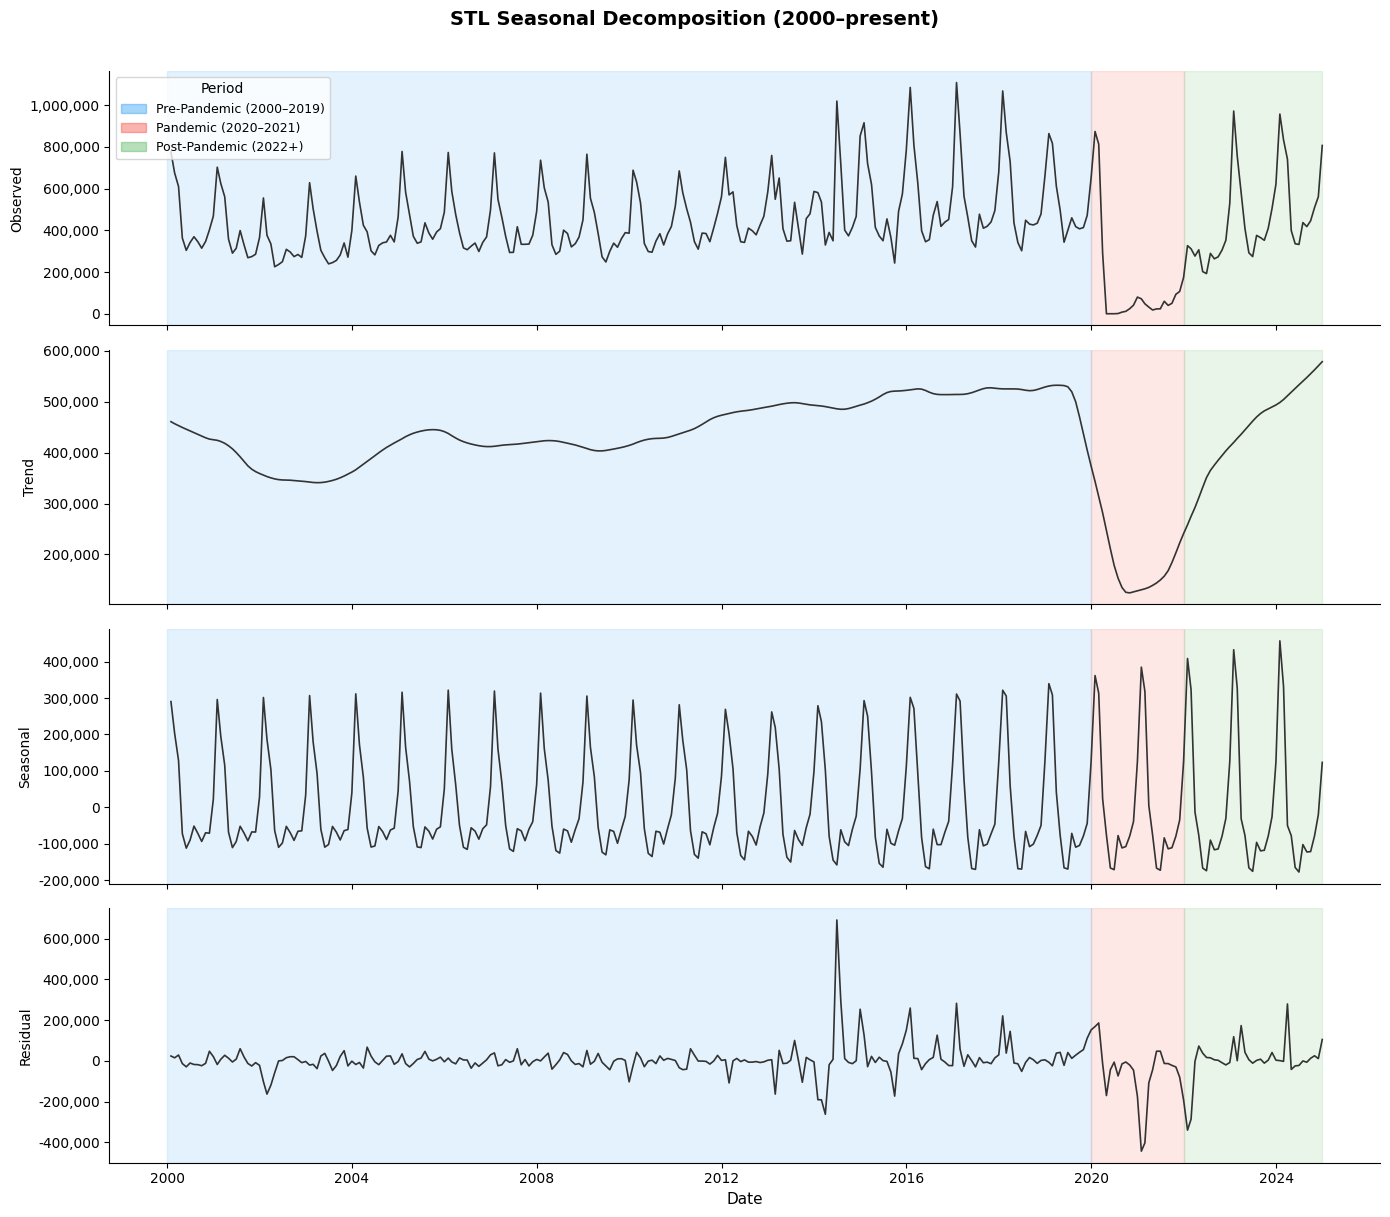

In [28]:
stl_series = monthly_df.loc[monthly_df['period'] != 'Legacy (< 2000)', 'arrival_count']

stl = STL(stl_series, period=12, seasonal=13, robust=True)
result = stl.fit()

components = [
    ('observed', 'Observed', result.observed),
    ('trend', 'Trend', result.trend),
    ('seasonal', 'Seasonal', result.seasonal),
    ('resid', 'Residual', result.resid),
]

period_spans = [
    (
        'Pre-Pandemic (2000–2019)',
        pd.Timestamp('2000-01-01'),
        pd.Timestamp('2019-12-31'),
    ),
    ('Pandemic (2020–2021)', COVID_START, COVID_END),
    ('Post-Pandemic (2022+)', pd.Timestamp('2022-01-01'), stl_series.index[-1]),
]

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle(
    'STL Seasonal Decomposition (2000–present)',
    fontsize=14,
    fontweight='bold',
    y=1.01,
)

for ax, (_, label, component) in zip(axes, components):
    ax.plot(component.index, component.values, color='#333333', linewidth=1.2)

    for period, start, end in period_spans:
        ax.axvspan(start, end, alpha=0.12, color=period_colors[period], label=period)

    ax.set_ylabel(label, fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(ax=ax)

# single shared legend on the top subplot
handles = [
    plt.Rectangle((0, 0), 1, 1, color=period_colors[p], alpha=0.4)
    for p in [
        'Pre-Pandemic (2000–2019)',
        'Pandemic (2020–2021)',
        'Post-Pandemic (2022+)',
    ]
]
labels = ['Pre-Pandemic (2000–2019)', 'Pandemic (2020–2021)', 'Post-Pandemic (2022+)']
axes[0].legend(
    handles, labels, title='Period', loc='upper left', frameon=True, fontsize=9
)

axes[-1].set_xlabel('Date', fontsize=11)
plt.tight_layout()
plt.show()

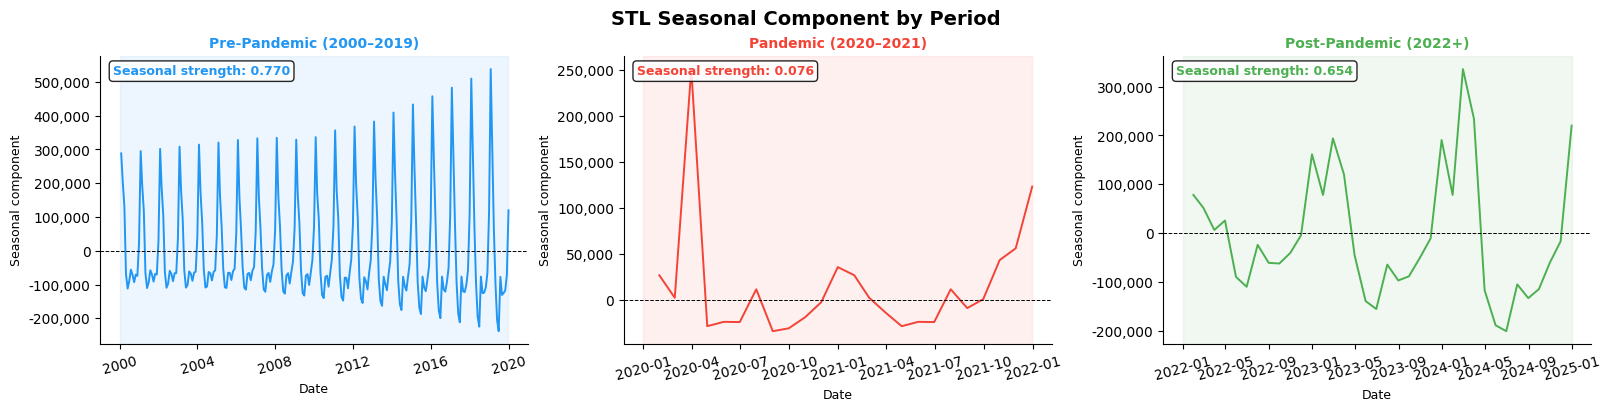

                           Seasonal Strength
Period                                      
Full Period (2000–present)            0.7107
Pre-Pandemic (2000–2019)              0.7700
Pandemic (2020–2021)                  0.0759
Post-Pandemic (2022+)                 0.6543


In [29]:
def stl_seasonal_strength(result):
    """max(0, 1 - Var(resid) / Var(seasonal + resid))"""
    var_resid = np.var(result.resid)
    var_seasonal_resid = np.var(result.seasonal + result.resid)
    return max(0.0, 1 - var_resid / var_seasonal_resid)


seasonal_periods = [
    (
        'Pre-Pandemic (2000–2019)',
        pd.Timestamp('2000-01-01'),
        pd.Timestamp('2019-12-31'),
    ),
    ('Pandemic (2020–2021)', COVID_START, COVID_END),
    ('Post-Pandemic (2022+)', pd.Timestamp('2022-01-01'), monthly_df.index[-1]),
]

# ── fit STL for full period + each sub-period ─────────────────────────────────
post_2000 = monthly_df[monthly_df['period'] != 'Legacy (< 2000)']

full_series = post_2000['arrival_count'].dropna()
full_result = STL(full_series, period=12, seasonal=13, robust=True).fit()
full_strength = stl_seasonal_strength(full_result)

period_stl = {}
for period, start, end in seasonal_periods:
    seg = monthly_df[(monthly_df.index >= start) & (monthly_df.index <= end)]
    series = seg['arrival_count'].dropna()
    # pandemic is too short for STL with seasonal=13; use seasonal=7
    s_window = 7 if len(series) < 36 else 13
    result = STL(series, period=12, seasonal=s_window, robust=True).fit()
    period_stl[period] = dict(result=result, strength=stl_seasonal_strength(result))

# ── 1×3 seasonal component plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
fig.suptitle('STL Seasonal Component by Period', fontsize=14, fontweight='bold')

for ax, (period, start, end) in zip(axes, seasonal_periods):
    color = period_colors[period]
    res = period_stl[period]['result']
    fs = period_stl[period]['strength']

    ax.plot(res.seasonal.index, res.seasonal.values, color=color, linewidth=1.4)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.axvspan(start, end, alpha=0.08, color=color)

    ax.annotate(
        f'Seasonal strength: {fs:.3f}',
        xy=(0.03, 0.97),
        xycoords='axes fraction',
        va='top',
        fontsize=9,
        color=color,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85),
    )
    ax.set_title(period, fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('Seasonal component', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='x', rotation=15)
    sns.despine(ax=ax)

plt.show()

# ── summary table ─────────────────────────────────────────────────────────────
summary_seasonal = pd.DataFrame(
    [('Full Period (2000–present)', f'{full_strength:.4f}')]
    + [(p, f'{period_stl[p]["strength"]:.4f}') for p, _, _ in seasonal_periods],
    columns=['Period', 'Seasonal Strength'],
).set_index('Period')

print(summary_seasonal.to_string())

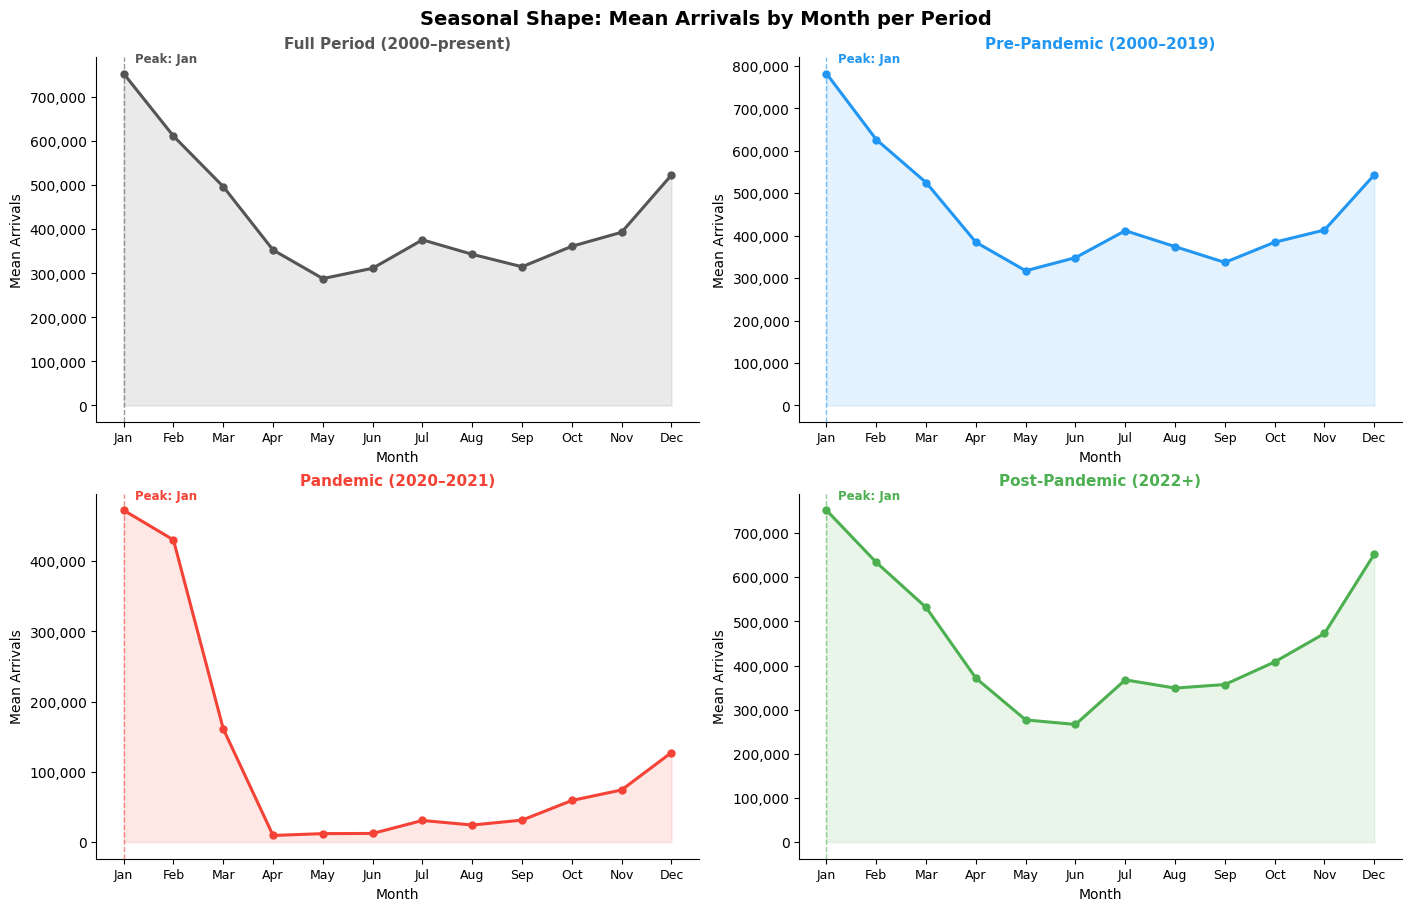

In [30]:
month_labels = [
    'Jan',
    'Feb',
    'Mar',
    'Apr',
    'May',
    'Jun',
    'Jul',
    'Aug',
    'Sep',
    'Oct',
    'Nov',
    'Dec',
]

shape_panels = [
    (
        'Full Period (2000–present)',
        monthly_df[monthly_df['period'] != 'Legacy (< 2000)'],
        '#555555',
    ),
    (
        'Pre-Pandemic (2000–2019)',
        monthly_df[monthly_df['period'] == 'Pre-Pandemic (2000–2019)'],
        period_colors['Pre-Pandemic (2000–2019)'],
    ),
    (
        'Pandemic (2020–2021)',
        monthly_df[monthly_df['period'] == 'Pandemic (2020–2021)'],
        period_colors['Pandemic (2020–2021)'],
    ),
    (
        'Post-Pandemic (2022+)',
        monthly_df[monthly_df['period'] == 'Post-Pandemic (2022+)'],
        period_colors['Post-Pandemic (2022+)'],
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
fig.suptitle(
    'Seasonal Shape: Mean Arrivals by Month per Period', fontsize=14, fontweight='bold'
)

for ax, (label, segment, color) in zip(axes.flat, shape_panels):
    monthly_means = (
        segment['arrival_count']
        .groupby(segment.index.month)
        .mean()
        .reindex(range(1, 13))
    )

    ax.plot(
        range(1, 13),
        monthly_means.values,
        color=color,
        linewidth=2.2,
        marker='o',
        markersize=5,
    )
    ax.fill_between(range(1, 13), monthly_means.values, alpha=0.12, color=color)

    peak_month = monthly_means.idxmax()
    ax.axvline(peak_month, color=color, linewidth=1, linestyle='--', alpha=0.6)
    ax.annotate(
        f'Peak: {month_labels[peak_month - 1]}',
        xy=(peak_month, monthly_means[peak_month]),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=8.5,
        color=color,
        fontweight='bold',
    )

    ax.set_title(label, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Month', fontsize=10)
    ax.set_ylabel('Mean Arrivals', fontsize=10)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    sns.despine(ax=ax)

plt.show()

##### Statistical Seasonality Test

`check_seasonality` (Joseph & Tackes, *Modern Time Series Forecasting with Python* 2E,
`src/transforms/stationary_utils.py`, adapted by the authors from `darts`) finds local
maxima of the ACF and accepts a candidate lag *m* when its autocorrelation exceeds a
Bartlett-formula confidence band. It is run in two modes:

- **Inferred**: the first significant ACF peak, searched up to `max_lag`.
- **Tested at m = 12**: checks whether lag 12 is a local ACF maximum and significant.

A strong trend dominates the ACF and can hide the seasonal peaks, so the test is also
repeated after linear detrending with `DetrendingTransformer` (same source,
`src/transforms/target_transformations.py`), which is the order the
`AutoStationaryTransformer` uses.

In [31]:
# Helpers `check_seasonality` / `DetrendingTransformer` from Joseph & Tackes,
# "Modern Time Series Forecasting with Python" 2E — src/transforms/


def seasonality_row(series, variant):
    n = len(series)
    inferred = check_seasonality(
        series, max_lag=min(36, n - 1), confidence=0.05, verbose=False
    )
    at_12 = (
        check_seasonality(
            series,
            max_lag=min(36, n - 1),
            seasonal_period=SEASONAL_PERIOD,
            confidence=0.05,
            verbose=False,
        )
        if n - 1 > SEASONAL_PERIOD
        else None
    )
    return {
        'Variant': variant,
        'n': n,
        'Inferred seasonal': '✓' if inferred.seasonal else '✗',
        'Inferred period': int(inferred.seasonal_periods) if inferred.seasonal else '—',
        'Seasonal at m=12': '—' if at_12 is None else ('✓' if at_12.seasonal else '✗'),
    }


seasonality_rows = []
for label, series in period_series.items():
    detrended = DetrendingTransformer(degree=1).fit_transform(series, freq=FREQ)
    for variant, s in [('Raw', series), ('Detrended (linear)', detrended)]:
        seasonality_rows.append({'Period': label, **seasonality_row(s, variant)})

seasonality_tests = pd.DataFrame(seasonality_rows).set_index(['Period', 'Variant'])

print('=' * 90)
print('SEASONALITY TEST — ACF local maxima + Bartlett band (check_seasonality)')
print('=' * 90)
print(seasonality_tests.to_string())

SEASONALITY TEST — ACF local maxima + Bartlett band (check_seasonality)
                                                 n Inferred seasonal Inferred period Seasonal at m=12
Period                     Variant                                                                   
Full Period (2000–present) Raw                 300                 ✓               6                ✓
                           Detrended (linear)  300                 ✓               6                ✓
Pre-Pandemic (2000–2019)   Raw                 240                 ✓              12                ✓
                           Detrended (linear)  240                 ✓              12                ✓
Pandemic (2020–2021)       Raw                  24                 ✗               —                ✗
                           Detrended (linear)   24                 ✓              22                ✗
Post-Pandemic (2022+)      Raw                  36                 ✓              12                ✓
          

#### Stationarity

STATIONARITY TEST RESULTS — ADF + KPSS
ADF  H0: unit root (non-stationary) → reject (p < 0.05) = stationary
KPSS H0: stationary                 → reject (p < 0.05) = non-stationary
                  Period   Transformation  ADF p ADF stationary  KPSS p KPSS stationary  Joint verdict
     Full (2000–present)              Raw 0.0610              ✗  0.1000               ✓      Ambiguous
     Full (2000–present)          Diff(1) 0.0000              ✓  0.1000               ✓     Stationary
     Full (2000–present)         Diff(12) 0.0037              ✓  0.1000               ✓     Stationary
     Full (2000–present) Diff(1)+Diff(12) 0.0000              ✓  0.1000               ✓     Stationary
Pre-Pandemic (2000–2019)              Raw 0.7147              ✗  0.0100               ✗ Non-stationary
Pre-Pandemic (2000–2019)          Diff(1) 0.0000              ✓  0.1000               ✓     Stationary
Pre-Pandemic (2000–2019)         Diff(12) 0.0001              ✓  0.1000               ✓     Statio

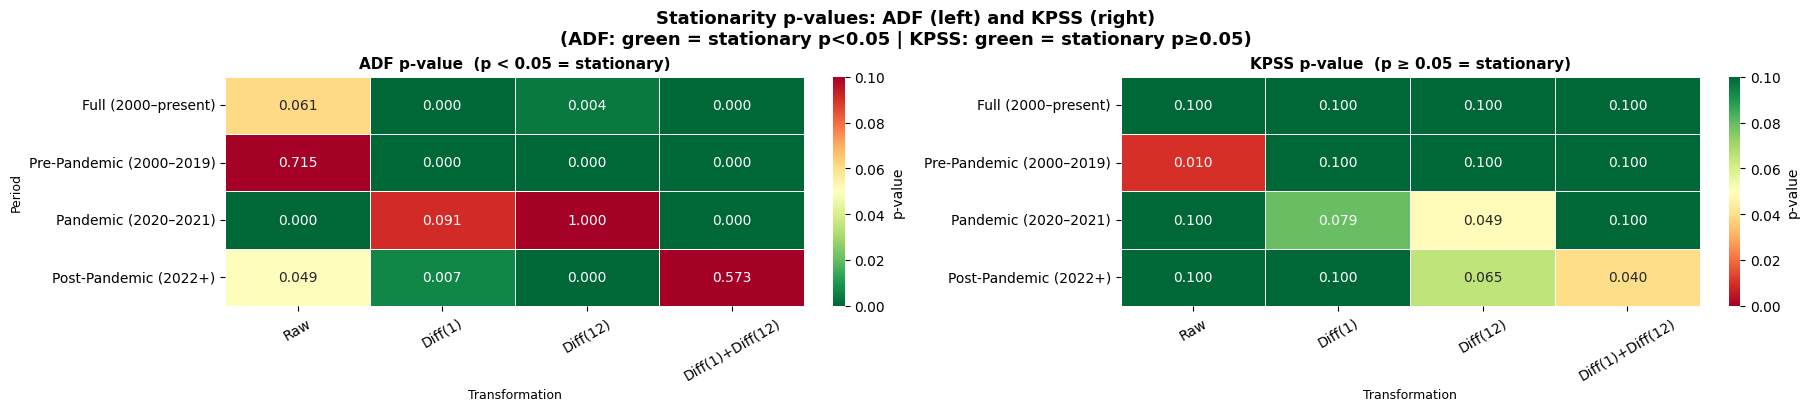

In [32]:
def run_adf(series, label):
    """ADF: H0 = unit root (non-stationary). p < 0.05 → stationary."""
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'label': label,
        'stat': result[0],
        'p': result[1],
        'lags': result[2],
        'stationary_adf': result[1] < 0.05,
    }


def run_kpss(series, label):
    """KPSS: H0 = stationary. p < 0.05 → non-stationary."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        stat, p, lags, _ = kpss(series.dropna(), regression='c', nlags='auto')
    return {
        'label': label,
        'stat': stat,
        'p': p,
        'lags': lags,
        'stationary_kpss': p >= 0.05,
    }


def joint_verdict(adf_row, kpss_row):
    """
    ADF stationary + KPSS stationary → Stationary
    ADF non-stationary + KPSS non-stationary → Non-stationary
    Disagreement → ambiguous (difference and retest)
    """
    a, k = adf_row['stationary_adf'], kpss_row['stationary_kpss']
    if a and k:
        return 'Stationary'
    if not a and not k:
        return 'Non-stationary'
    return 'Ambiguous'


def test_series(series, label):
    a = run_adf(series, label)
    k = run_kpss(series, label)
    return a, k, joint_verdict(a, k)


def stationarity_grid(periods, transformations):
    """Run ADF + KPSS for every (period, transformation) pair."""
    rows = []
    for period_label, raw_series in periods:
        for trans_label, fn in transformations:
            try:
                s = fn(raw_series, period_label).dropna()
                if len(s) < 8:
                    continue
                adf_r, kpss_r, verdict = test_series(
                    s, f'{period_label} | {trans_label}'
                )
                rows.append({
                    'Period': period_label,
                    'Transformation': trans_label,
                    'ADF stat': round(adf_r['stat'], 4),
                    'ADF p': round(adf_r['p'], 4),
                    'ADF lags': adf_r['lags'],
                    'ADF stationary': '✓' if adf_r['stationary_adf'] else '✗',
                    'KPSS stat': round(kpss_r['stat'], 4),
                    'KPSS p': round(kpss_r['p'], 4),
                    'KPSS stationary': '✓' if kpss_r['stationary_kpss'] else '✗',
                    'Joint verdict': verdict,
                })
            except Exception as e:
                rows.append({
                    'Period': period_label,
                    'Transformation': trans_label,
                    'ADF stat': None,
                    'ADF p': None,
                    'ADF lags': None,
                    'ADF stationary': 'ERR',
                    'KPSS stat': None,
                    'KPSS p': None,
                    'KPSS stationary': 'ERR',
                    'Joint verdict': str(e),
                })
    return pd.DataFrame(rows)


def plot_stationarity_heatmaps(stat_df, trans_order, period_label_order, title):
    pivot_adf = stat_df.pivot_table(
        index='Period', columns='Transformation', values='ADF p', aggfunc='first'
    ).reindex(index=period_label_order, columns=trans_order)
    pivot_kpss = stat_df.pivot_table(
        index='Period', columns='Transformation', values='KPSS p', aggfunc='first'
    ).reindex(index=period_label_order, columns=trans_order)

    fig, axes = plt.subplots(1, 2, figsize=(18, 4), constrained_layout=True)
    fig.suptitle(
        f'{title}\n(ADF: green = stationary p<0.05 | KPSS: green = stationary p≥0.05)',
        fontsize=13,
        fontweight='bold',
    )

    # ADF heatmap: low p → stationary → green
    sns.heatmap(
        pivot_adf.astype(float),
        ax=axes[0],
        annot=True,
        fmt='.3f',
        cmap='RdYlGn_r',
        vmin=0,
        vmax=0.1,
        linewidths=0.4,
        cbar_kws={'label': 'p-value'},
    )
    axes[0].set_title(
        'ADF p-value  (p < 0.05 = stationary)', fontsize=11, fontweight='bold'
    )

    # KPSS heatmap: high p → stationary → green
    sns.heatmap(
        pivot_kpss.astype(float),
        ax=axes[1],
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        vmin=0,
        vmax=0.1,
        linewidths=0.4,
        cbar_kws={'label': 'p-value'},
    )
    axes[1].set_title(
        'KPSS p-value  (p ≥ 0.05 = stationary)', fontsize=11, fontweight='bold'
    )
    axes[1].set_ylabel('')

    for ax in axes:
        ax.set_xlabel('Transformation', fontsize=9)
        ax.tick_params(axis='x', rotation=30)
        ax.tick_params(axis='y', rotation=0)
    axes[0].set_ylabel('Period', fontsize=9)

    plt.show()


# ── series variants to test ───────────────────────────────────────────────────

stationarity_periods = [
    (
        'Full (2000–present)',
        monthly_df[monthly_df['period'] != 'Legacy (< 2000)']['arrival_count'],
    ),
    (
        'Pre-Pandemic (2000–2019)',
        monthly_df[monthly_df['period'] == 'Pre-Pandemic (2000–2019)']['arrival_count'],
    ),
    (
        'Pandemic (2020–2021)',
        monthly_df[monthly_df['period'] == 'Pandemic (2020–2021)']['arrival_count'],
    ),
    (
        'Post-Pandemic (2022+)',
        monthly_df[monthly_df['period'] == 'Post-Pandemic (2022+)']['arrival_count'],
    ),
]
period_label_order = [p for p, _ in stationarity_periods]

transformations = [
    ('Raw', lambda s, _: s),
    ('Diff(1)', lambda s, _: s.diff(1)),
    ('Diff(12)', lambda s, _: s.diff(12)),
    ('Diff(1)+Diff(12)', lambda s, _: s.diff(1).diff(12)),
]
trans_order = [t for t, _ in transformations]

# ── run all tests ─────────────────────────────────────────────────────────────

stat_df = stationarity_grid(stationarity_periods, transformations)

# ── display full table ────────────────────────────────────────────────────────

display_cols = [
    'Period',
    'Transformation',
    'ADF p',
    'ADF stationary',
    'KPSS p',
    'KPSS stationary',
    'Joint verdict',
]

print('=' * 100)
print('STATIONARITY TEST RESULTS — ADF + KPSS')
print('ADF  H0: unit root (non-stationary) → reject (p < 0.05) = stationary')
print('KPSS H0: stationary                 → reject (p < 0.05) = non-stationary')
print('=' * 100)
print(stat_df[display_cols].to_string(index=False))

# ── SARIMA order recommendation ───────────────────────────────────────────────

print()
print('=' * 70)
print('SARIMA DIFFERENCING RECOMMENDATION')
print('=' * 70)

for period_label, _ in stationarity_periods:
    sub = stat_df[stat_df['Period'] == period_label]

    def verdict_for(trans, sub=sub):
        row = sub[sub['Transformation'] == trans]
        return row['Joint verdict'].values[0] if len(row) else 'N/A'

    raw_v = verdict_for('Raw')
    d1_v = verdict_for('Diff(1)')
    d12_v = verdict_for('Diff(12)')
    d1d12_v = verdict_for('Diff(1)+Diff(12)')

    # infer d
    if raw_v == 'Stationary':
        d = 0
    elif d1_v == 'Stationary':
        d = 1
    else:
        d = 2

    # infer D (seasonal differencing, period=12)
    D = 0 if raw_v == 'Stationary' else 1

    print(f'\n{period_label}')
    print(f'  Raw              → {raw_v}')
    print(f'  Diff(1)          → {d1_v}')
    print(f'  Diff(12)         → {d12_v}')
    print(f'  Diff(1)+Diff(12) → {d1d12_v}')
    print(f'  Suggested: d={d}, D={D}, s=12  →  SARIMA(p, {d}, q)(P, {D}, Q)[12]')

# ── visual: heatmap of ADF / KPSS p-values ───────────────────────────────────

plot_stationarity_heatmaps(
    stat_df,
    trans_order,
    period_label_order,
    'Stationarity p-values: ADF (left) and KPSS (right)',
)

#### Auto correlation

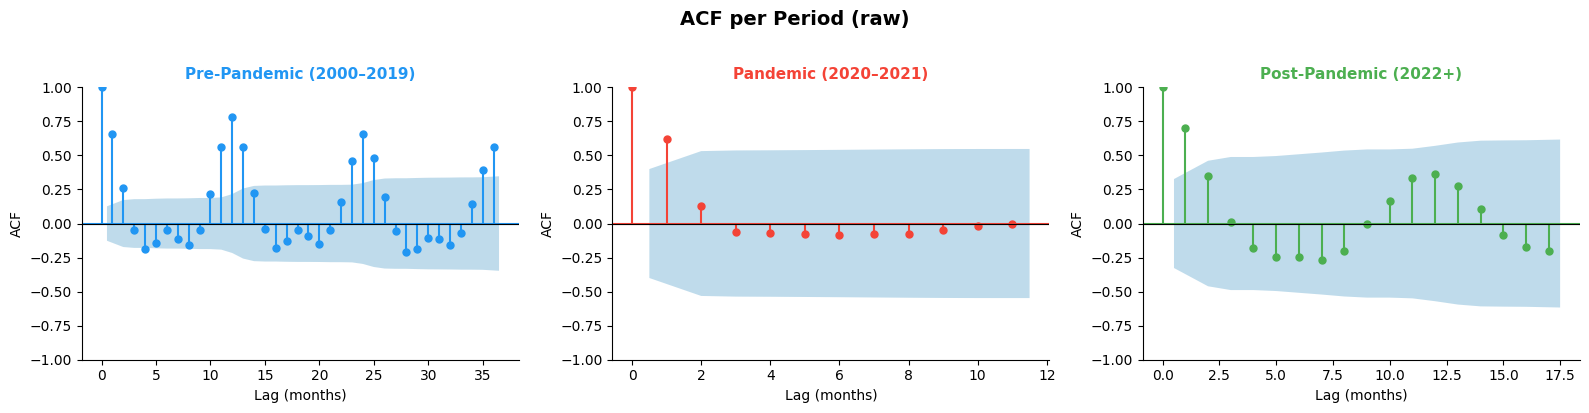

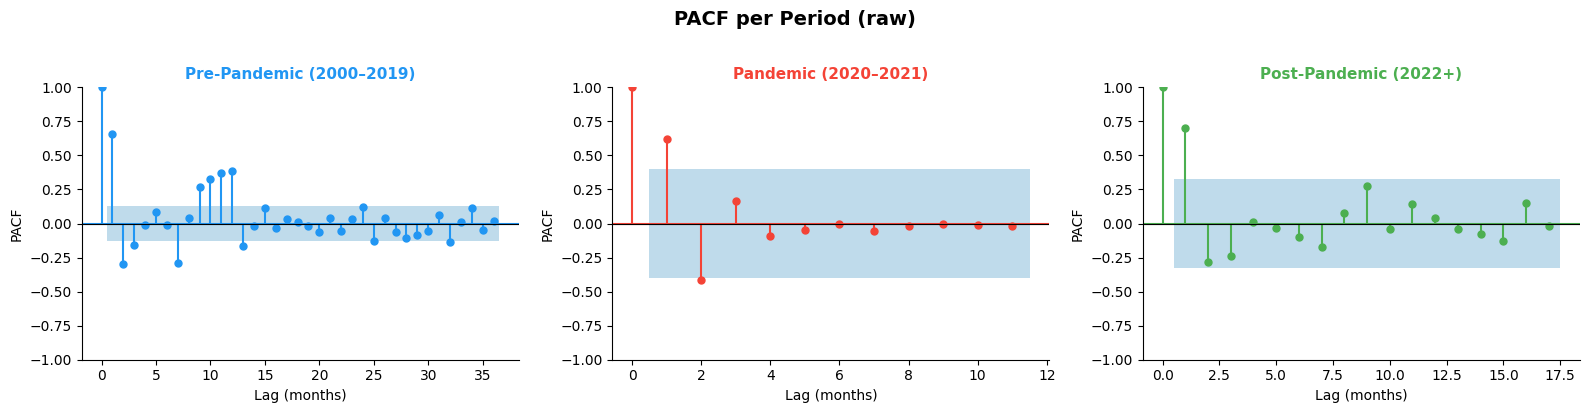

In [33]:
acf_periods = [
    'Pre-Pandemic (2000–2019)',
    'Pandemic (2020–2021)',
    'Post-Pandemic (2022+)',
]

for plot_fn, fn_label in [(plot_acf, 'ACF'), (plot_pacf, 'PACF')]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(
        f'{fn_label} per Period (raw)',
        fontsize=14,
        fontweight='bold',
        y=1.02,
    )

    for ax, period in zip(axes, acf_periods):
        series = monthly_df.loc[monthly_df['period'] == period, 'arrival_count']
        lags = min(36, len(series) // 2 - 1)
        color = period_colors[period]

        plot_fn(series, lags=lags, ax=ax, color=color, vlines_kwargs={'colors': color})

        ax.set_title(period, fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Lag (months)', fontsize=10)
        ax.set_ylabel(fn_label, fontsize=10)
        ax.axhline(0, color='black', linewidth=0.8)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

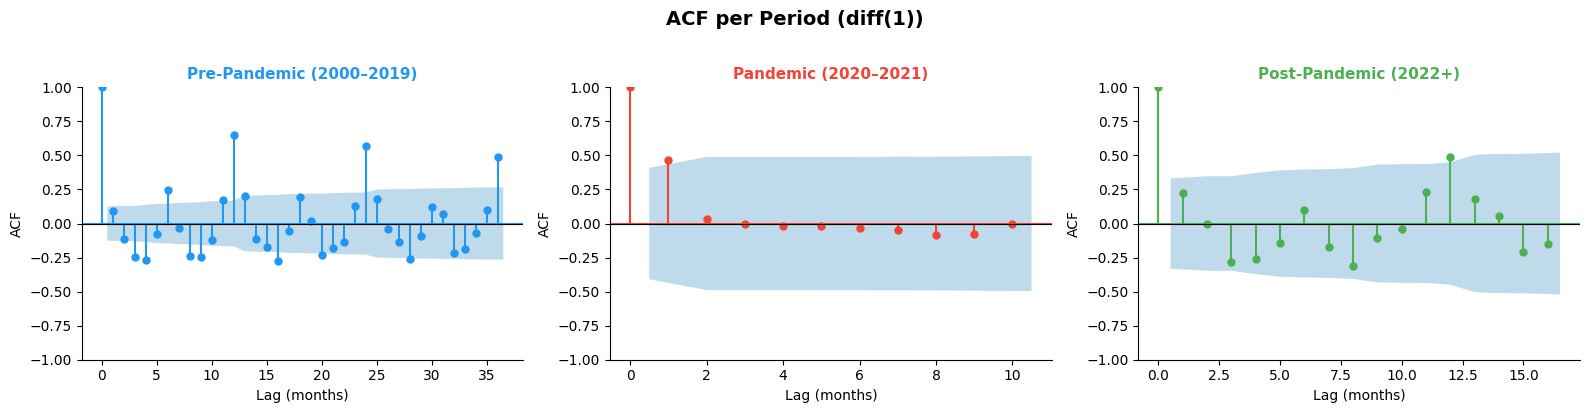

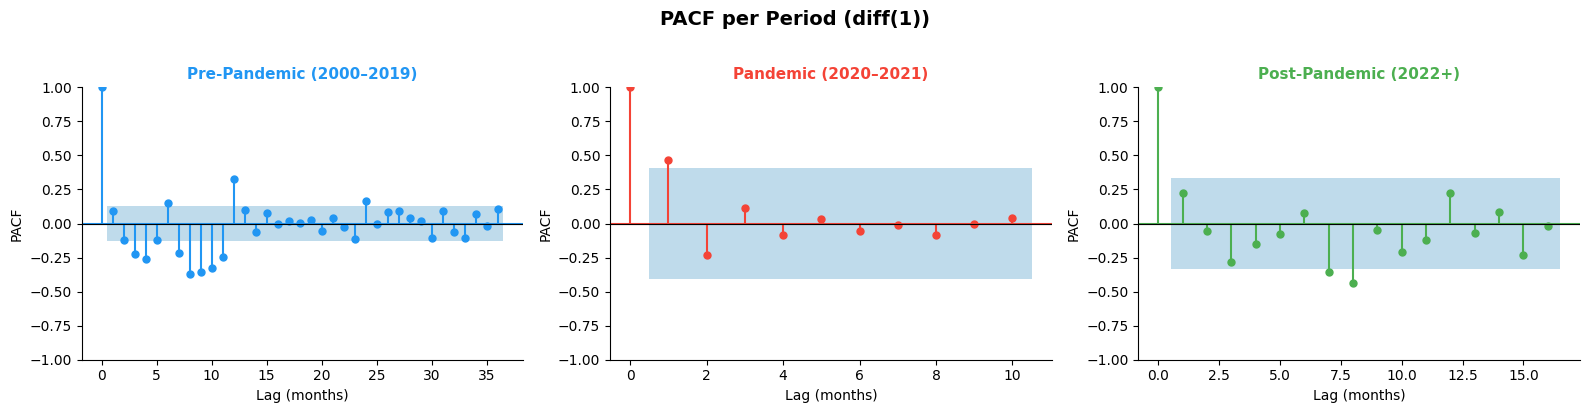

In [34]:
for plot_fn, fn_label in [(plot_acf, 'ACF'), (plot_pacf, 'PACF')]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(
        f'{fn_label} per Period (diff(1))',
        fontsize=14,
        fontweight='bold',
        y=1.02,
    )

    for ax, period in zip(axes, acf_periods):
        series = (
            monthly_df
            .loc[monthly_df['period'] == period, 'arrival_count']
            .diff(1)
            .dropna()
        )
        lags = min(36, len(series) // 2 - 1)
        color = period_colors[period]

        plot_fn(series, lags=lags, ax=ax, color=color, vlines_kwargs={'colors': color})

        ax.set_title(period, fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Lag (months)', fontsize=10)
        ax.set_ylabel(fn_label, fontsize=10)
        ax.axhline(0, color='black', linewidth=0.8)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

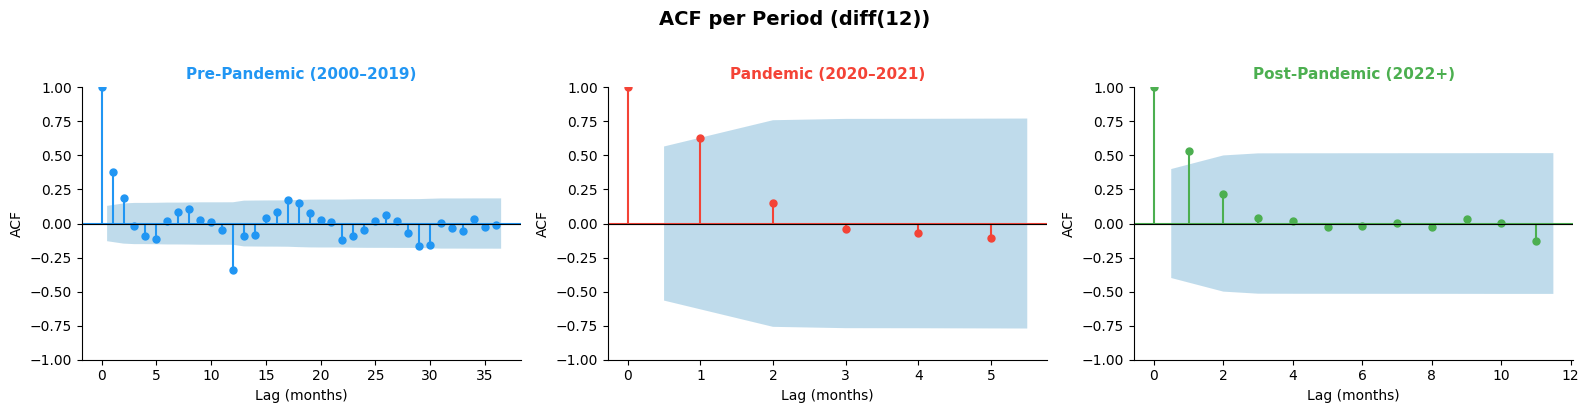

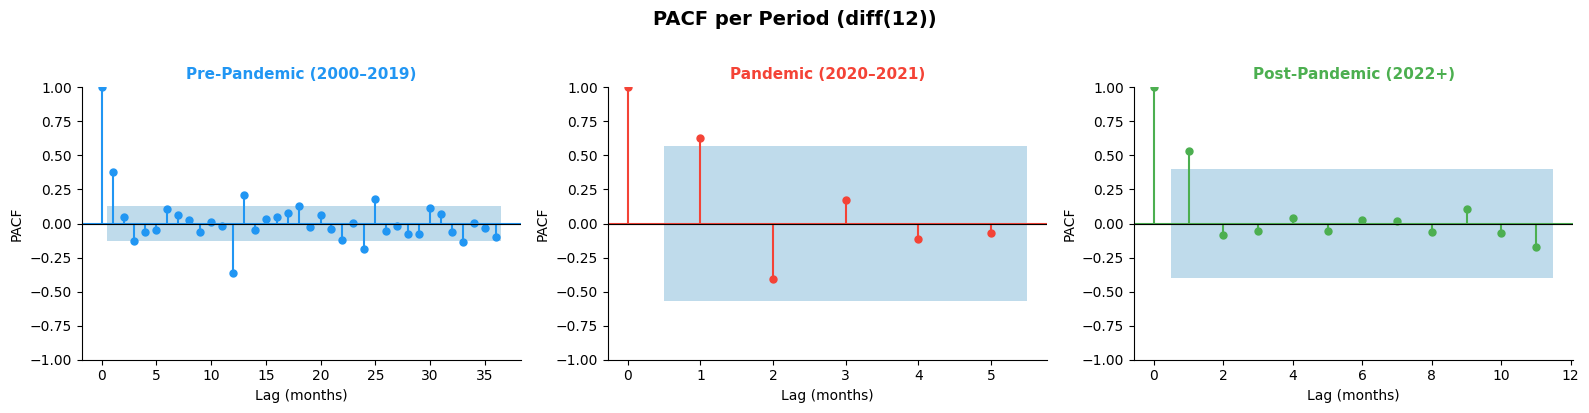

In [35]:
for plot_fn, fn_label in [(plot_acf, 'ACF'), (plot_pacf, 'PACF')]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(
        f'{fn_label} per Period (diff(12))',
        fontsize=14,
        fontweight='bold',
        y=1.02,
    )

    for ax, period in zip(axes, acf_periods):
        series = (
            monthly_df
            .loc[monthly_df['period'] == period, 'arrival_count']
            .diff(12)
            .dropna()
        )
        lags = min(36, len(series) // 2 - 1)
        color = period_colors[period]

        plot_fn(series, lags=lags, ax=ax, color=color, vlines_kwargs={'colors': color})

        ax.set_title(period, fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Lag (months)', fontsize=10)
        ax.set_ylabel(fn_label, fontsize=10)
        ax.axhline(0, color='black', linewidth=0.8)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

#### Heteroscedasticity

A series is heteroscedastic when its variance changes over time. For tourism arrivals
this usually shows up as a seasonal amplitude that grows with the level of the series.
This is what the mean–std check in the *Trend* section suggests. It matters because
ARIMA-type models assume constant error variance. Level-dependent variance also makes
the prediction intervals too narrow at the peaks and too wide at the troughs.

Two complementary checks:

1. **Visual**: 12-month rolling mean, rolling standard deviation and rolling coefficient
   of variation (std / mean). A constant CV together with a growing std points to
   multiplicative behaviour.
2. **White test** via `check_heteroscedastisticity` (Joseph & Tackes, *Modern Time Series
   Forecasting with Python* 2E, `src/transforms/stationary_utils.py`). The helper fits a
   linear trend and runs White's test on the residuals (H0: homoscedastic). It is applied
   to the raw series and to the series after linear detrending and period-average
   deseasonalizing (`DetrendingTransformer` → `DeseasonalizingTransformer`, same source).
   This way, the seasonal cycle is not mistaken for changing variance.

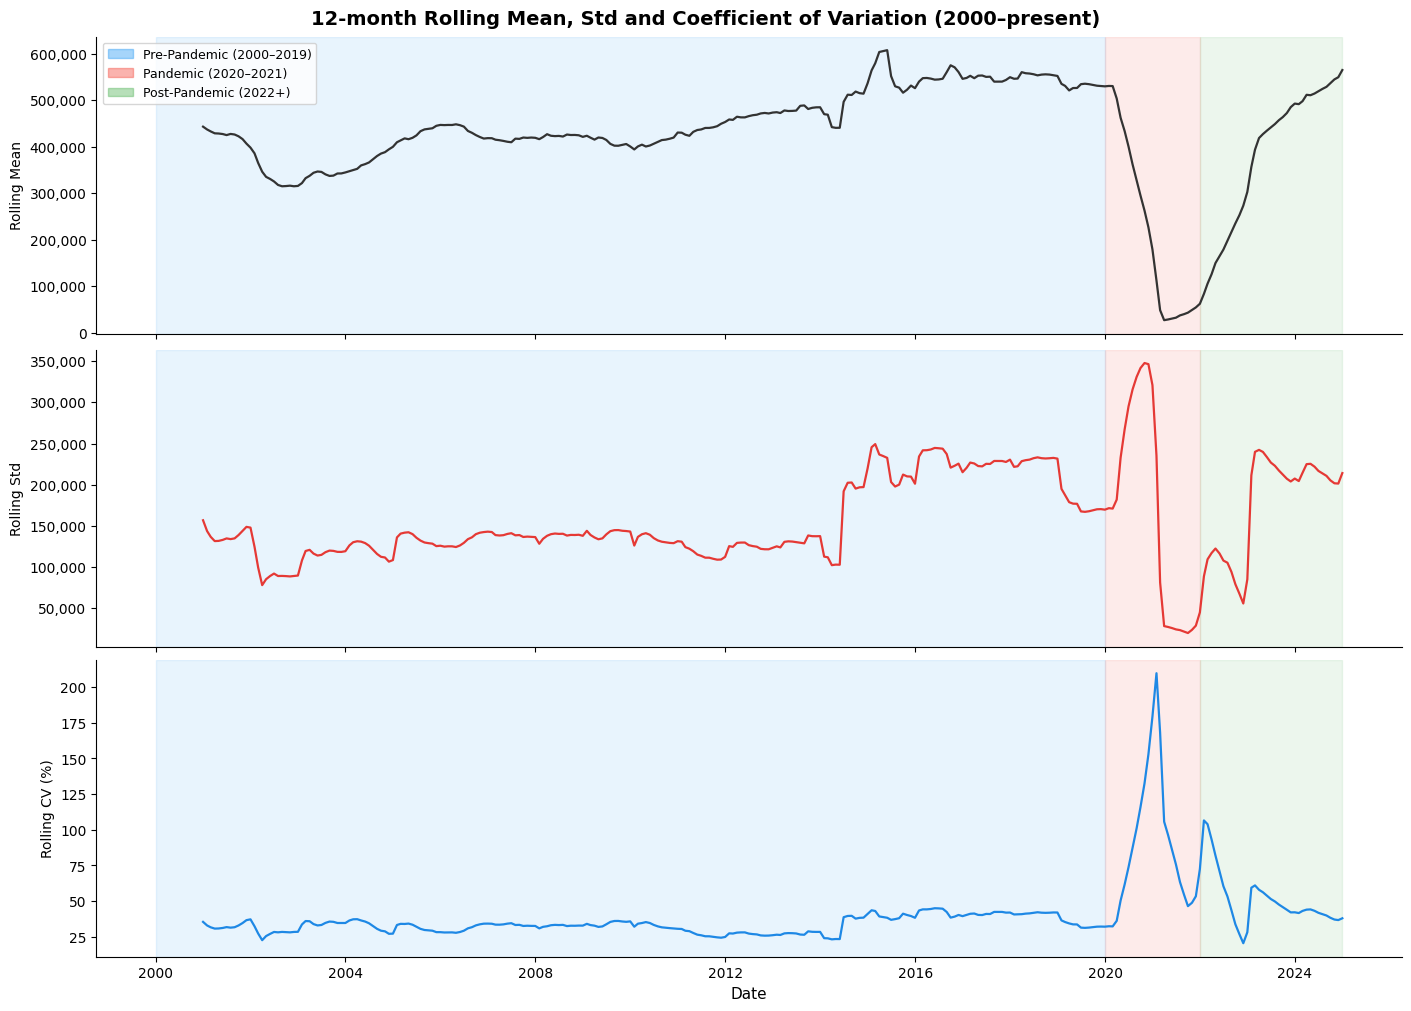

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, constrained_layout=True)
fig.suptitle(
    '12-month Rolling Mean, Std and Coefficient of Variation (2000–present)',
    fontsize=14,
    fontweight='bold',
)

full_series = period_series['Full Period (2000–present)']
rolling_mean = full_series.rolling(12).mean()
rolling_std = full_series.rolling(12).std()
rolling_cv = rolling_std / rolling_mean * 100

for ax, values, label, color in [
    (axes[0], rolling_mean, 'Rolling Mean', '#333333'),
    (axes[1], rolling_std, 'Rolling Std', '#e53935'),
    (axes[2], rolling_cv, 'Rolling CV (%)', '#1e88e5'),
]:
    ax.plot(values.index, values, color=color, linewidth=1.6)
    for period, start, end in trend_periods:
        ax.axvspan(start, end, alpha=0.1, color=period_colors[period])
    ax.set_ylabel(label, fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    sns.despine(ax=ax)

axes[0].legend(
    handles=[
        mpatches.Patch(color=period_colors[p], alpha=0.4, label=p)
        for p, _, _ in trend_periods
    ],
    fontsize=9,
    frameon=True,
    loc='upper left',
)
axes[-1].set_xlabel('Date', fontsize=11)
plt.show()

In [37]:
# Helpers `check_heteroscedastisticity`, `DetrendingTransformer` and
# `DeseasonalizingTransformer` from Joseph & Tackes, "Modern Time Series Forecasting
# with Python" 2E — src/transforms/


def detrend_deseasonalize(series):
    """Linear detrend + period-average deseasonalize (AutoStationary order)."""
    detrended = DetrendingTransformer(degree=1).fit_transform(series, freq=FREQ)
    if len(detrended) <= 2 * SEASONAL_PERIOD:
        return detrended
    return DeseasonalizingTransformer(
        seasonal_period=SEASONAL_PERIOD, seasonality_extraction='period_averages'
    ).fit_transform(detrended, freq=FREQ)


def white_row(series, variant):
    res = check_heteroscedastisticity(series, confidence=0.05)
    return {
        'Variant': variant,
        'White LM stat': round(res.lm_statistic, 3),
        'White LM p': round(res.lm_p_value, 4),
        'Heteroscedastic': '✓' if res.heteroscedastic else '✗',
    }


hetero_rows = []
for label, series in period_series.items():
    hetero_rows.append({'Period': label, **white_row(series, 'Raw')})
    hetero_rows.append({
        'Period': label,
        **white_row(detrend_deseasonalize(series), 'Detrended + deseasonalized'),
    })

hetero_tests = pd.DataFrame(hetero_rows).set_index(['Period', 'Variant'])

print('=' * 90)
print('WHITE TEST — H0: homoscedastic → reject (LM and F p < 0.05) = heteroscedastic')
print('=' * 90)
print(hetero_tests.to_string())

WHITE TEST — H0: homoscedastic → reject (LM and F p < 0.05) = heteroscedastic
                                                       White LM stat  White LM p Heteroscedastic
Period                     Variant                                                              
Full Period (2000–present) Raw                                27.903      0.0000               ✓
                           Detrended + deseasonalized         31.458      0.0000               ✓
Pre-Pandemic (2000–2019)   Raw                                 7.947      0.0188               ✓
                           Detrended + deseasonalized          2.071      0.3550               ✗
Pandemic (2020–2021)       Raw                                15.017      0.0005               ✓
                           Detrended + deseasonalized         15.017      0.0005               ✓
Post-Pandemic (2022+)      Raw                                 2.362      0.3069               ✗
                           Detrended + deseasonal

#### Box-Cox Transformation (Guerrero λ)

Instead of fixing λ = 0 (log), the Box-Cox power transformation

$$
y^{(\lambda)} =
\begin{cases}
\dfrac{y^{\lambda} - 1}{\lambda}, & \lambda \neq 0 \\
\log y, & \lambda = 0
\end{cases}
$$

is fitted with λ chosen by **Guerrero's method** (Guerrero, 1993, *Journal of Forecasting*
12, 37–48). The series is split into consecutive seasonal blocks (m = 12, i.e. calendar
years). Guerrero picks the λ that makes $\sigma_h / \mu_h^{1-\lambda}$ as constant as
possible across blocks, measured by its coefficient of variation. In other words, λ is
the power that best removes the dependence between the level and the spread.

The transformation uses `BoxCoxTransformer(seasonal_period=12, optimization='guerrero',
bounds=(-1, 2))` from Joseph & Tackes, *Modern Time Series Forecasting with Python* 2E
(`src/transforms/target_transformations.py`). The Guerrero optimizer is adapted by the
authors from `sktime`.

Reading λ: **≈ 1** no transformation needed · **≈ 0.5** square root · **≈ 0** log ·
**< 0** inverse power (stronger than log).

                              n  Guerrero blocks (years)  λ (Guerrero)         Interpretation
Period                                                                                       
Full Period (2000–present)  300                       25        1.0752         ≈ none (λ ≈ 1)
Pre-Pandemic (2000–2019)    240                       20       -0.4562  inverse power (λ < 0)
Pandemic (2020–2021)         24                        2       -0.8569  inverse power (λ < 0)
Post-Pandemic (2022+)        36                        3       -0.5912  inverse power (λ < 0)


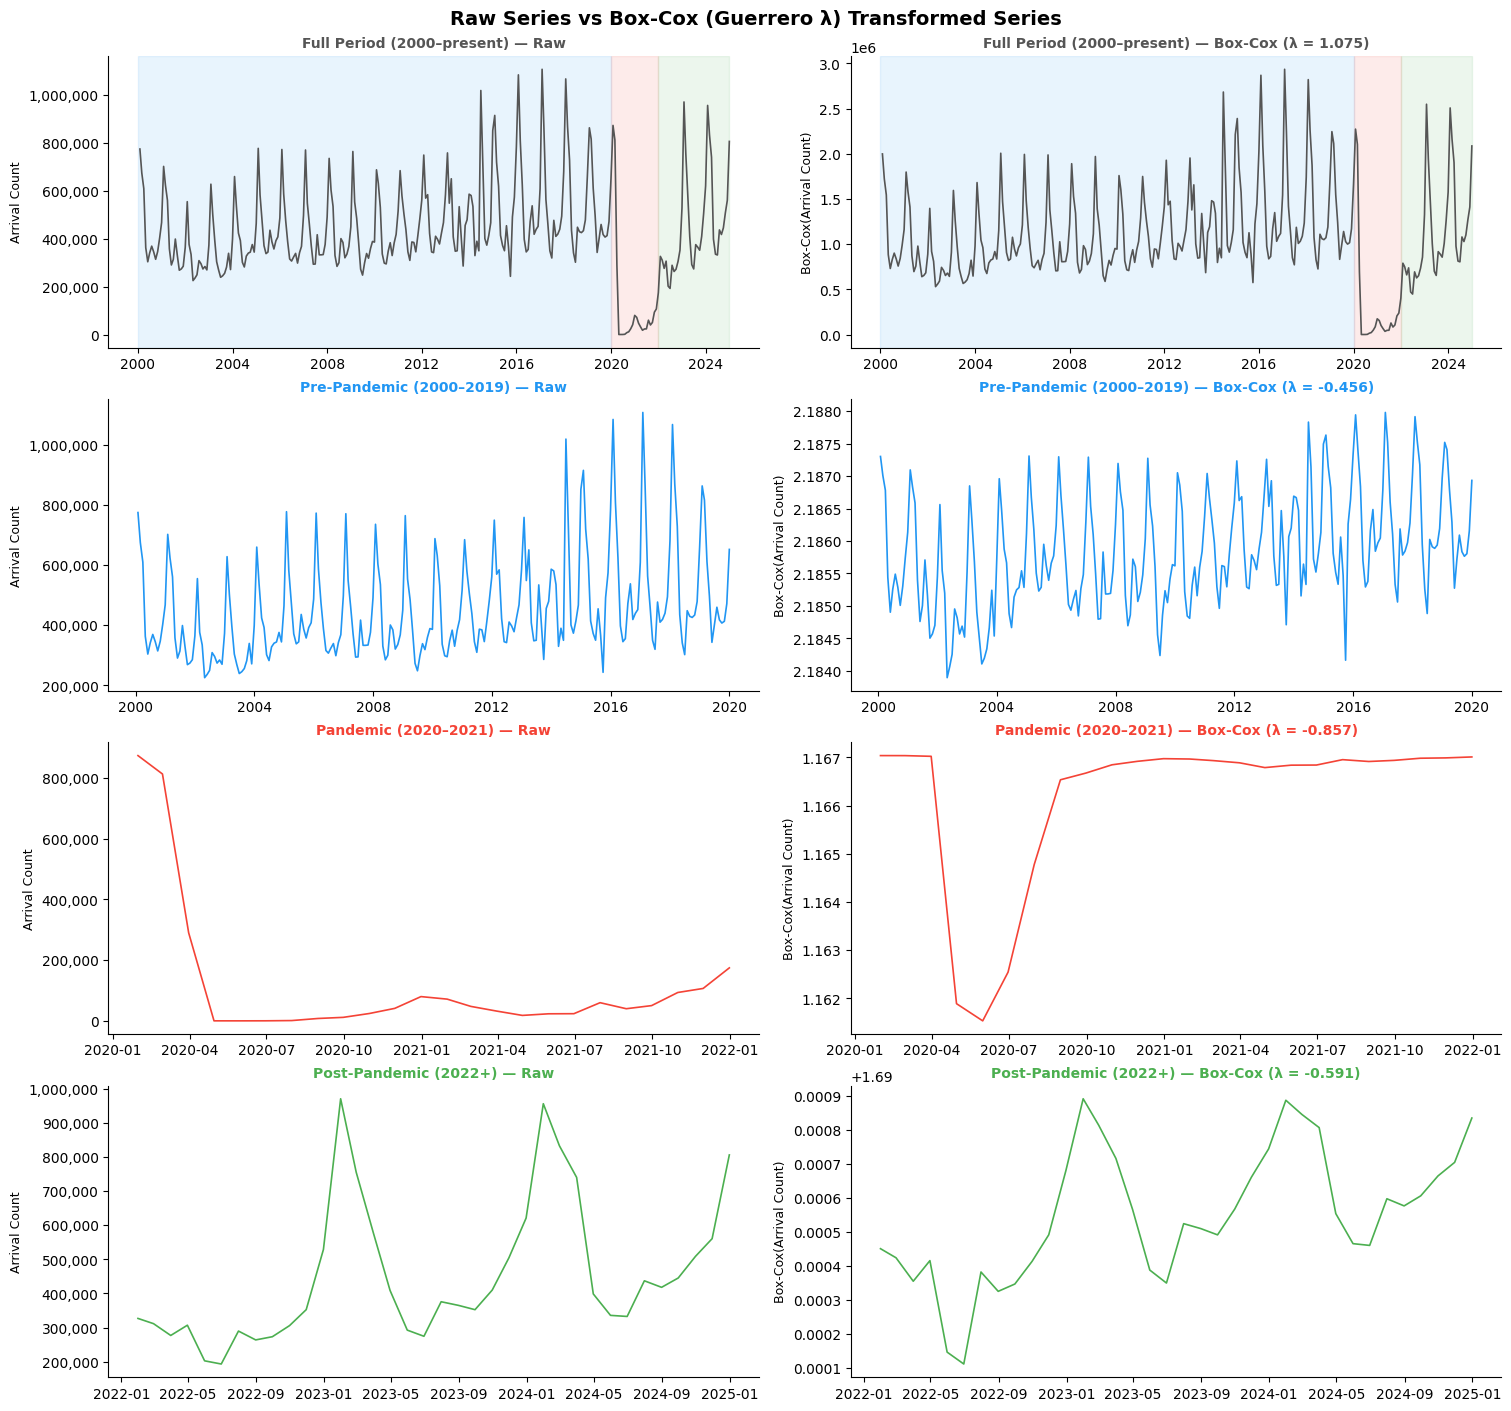

In [38]:
# Helper `BoxCoxTransformer` (Guerrero λ) from Joseph & Tackes, "Modern Time Series
# Forecasting with Python" 2E — src/transforms/target_transformations.py


def interpret_lambda(lmbda):
    if lmbda > 0.75:
        return '≈ none (λ ≈ 1)'
    if lmbda > 0.25:
        return '≈ square root (λ ≈ 0.5)'
    if lmbda > -0.25:
        return '≈ log (λ ≈ 0)'
    return 'inverse power (λ < 0)'


boxcox_fitted = {}
boxcox_series = {}
lambda_rows = []
for label, series in period_series.items():
    bc = BoxCoxTransformer(
        seasonal_period=SEASONAL_PERIOD, optimization='guerrero', bounds=(-1, 2)
    )
    bc.fit(series)
    boxcox_fitted[label] = bc
    boxcox_series[label] = bc.transform(series)
    lambda_rows.append({
        'Period': label,
        'n': len(series),
        'Guerrero blocks (years)': len(series) // SEASONAL_PERIOD,
        'λ (Guerrero)': round(bc.boxcox_lambda, 4),
        'Interpretation': interpret_lambda(bc.boxcox_lambda),
    })

boxcox_lambdas = pd.DataFrame(lambda_rows).set_index('Period')
print(boxcox_lambdas.to_string())

# ── raw vs Box-Cox per period ────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(15, 14), constrained_layout=True)
fig.suptitle(
    'Raw Series vs Box-Cox (Guerrero λ) Transformed Series',
    fontsize=14,
    fontweight='bold',
)

for row, (label, series) in enumerate(period_series.items()):
    color = period_series_colors[label]
    lmbda = boxcox_fitted[label].boxcox_lambda

    axes[row, 0].plot(series.index, series, color=color, linewidth=1.2)
    axes[row, 0].set_title(
        f'{label} — Raw', fontsize=10, fontweight='bold', color=color
    )
    axes[row, 0].set_ylabel('Arrival Count', fontsize=9)
    axes[row, 0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{int(x):,}')
    )

    transformed = boxcox_series[label]
    axes[row, 1].plot(transformed.index, transformed, color=color, linewidth=1.2)
    axes[row, 1].set_title(
        f'{label} — Box-Cox (λ = {lmbda:.3f})',
        fontsize=10,
        fontweight='bold',
        color=color,
    )
    axes[row, 1].set_ylabel('Box-Cox(Arrival Count)', fontsize=9)

    if label == 'Full Period (2000–present)':
        for period, start, end in trend_periods:
            for ax in axes[row]:
                ax.axvspan(start, end, alpha=0.1, color=period_colors[period])

    for ax in axes[row]:
        sns.despine(ax=ax)

plt.show()

##### Did Box-Cox stabilize the variance?

The same diagnostics are repeated on the Box-Cox scale:

- the annual mean–std correlation from the additive/multiplicative check (computed on the level series), and
- the White test, run on both scales **after** detrending and deseasonalizing (`detrend_deseasonalize` above).

The Pandemic period has only two calendar years, so its mean–std correlation is trivially ±1 and its Guerrero λ rests on two blocks. Treat that column as indicative only.

In [39]:
def mean_std_corr(series):
    annual = series.resample('YE').agg(['mean', 'std']).dropna()
    return annual['mean'].corr(annual['std'])


variance_rows = []
for label, series in period_series.items():
    transformed = boxcox_series[label]
    raw_white = check_heteroscedastisticity(detrend_deseasonalize(series))
    bc_white = check_heteroscedastisticity(detrend_deseasonalize(transformed))
    variance_rows.append({
        'Period': label,
        'λ': round(boxcox_fitted[label].boxcox_lambda, 3),
        'Mean–std corr (raw)': round(mean_std_corr(series), 3),
        'Mean–std corr (Box-Cox)': round(mean_std_corr(transformed), 3),
        'White p (raw scale)': round(raw_white.lm_p_value, 4),
        'White p (Box-Cox scale)': round(bc_white.lm_p_value, 4),
        'Heteroscedastic (raw scale)': '✓' if raw_white.heteroscedastic else '✗',
        'Heteroscedastic (Box-Cox scale)': '✓' if bc_white.heteroscedastic else '✗',
    })

variance_comparison = pd.DataFrame(variance_rows).set_index('Period')
print(variance_comparison.T.to_string())

Period                          Full Period (2000–present) Pre-Pandemic (2000–2019) Pandemic (2020–2021) Post-Pandemic (2022+)
λ                                                    1.075                   -0.456               -0.857                -0.591
Mean–std corr (raw)                                  0.391                     0.85                  1.0                 0.975
Mean–std corr (Box-Cox)                              0.459                    0.047                 -1.0                 0.284
White p (raw scale)                                    0.0                    0.355               0.0005                0.0122
White p (Box-Cox scale)                                0.0                    0.624               0.0059                0.0262
Heteroscedastic (raw scale)                              ✓                        ✗                    ✓                     ✓
Heteroscedastic (Box-Cox scale)                          ✓                        ✗                    ✓       

##### Stationarity on the Box-Cox Scale

The ADF + KPSS grid from the *Stationarity* section is re-run on the Box-Cox transformed
series. Each period uses its own Guerrero λ. This replaces the log-based variants that
were previously in that grid.

STATIONARITY TEST RESULTS — Box-Cox (Guerrero λ) variants
                  Period             Transformation  ADF p ADF stationary  KPSS p KPSS stationary  Joint verdict
     Full (2000–present)                    Box-Cox 0.0800              ✗  0.1000               ✓      Ambiguous
     Full (2000–present)          Box-Cox + Diff(1) 0.0000              ✓  0.1000               ✓     Stationary
     Full (2000–present)         Box-Cox + Diff(12) 0.0046              ✓  0.1000               ✓     Stationary
     Full (2000–present) Box-Cox + Diff(1)+Diff(12) 0.0000              ✓  0.1000               ✓     Stationary
Pre-Pandemic (2000–2019)                    Box-Cox 0.6925              ✗  0.0100               ✗ Non-stationary
Pre-Pandemic (2000–2019)          Box-Cox + Diff(1) 0.0000              ✓  0.1000               ✓     Stationary
Pre-Pandemic (2000–2019)         Box-Cox + Diff(12) 0.0009              ✓  0.1000               ✓     Stationary
Pre-Pandemic (2000–2019) Box-Cox + Dif

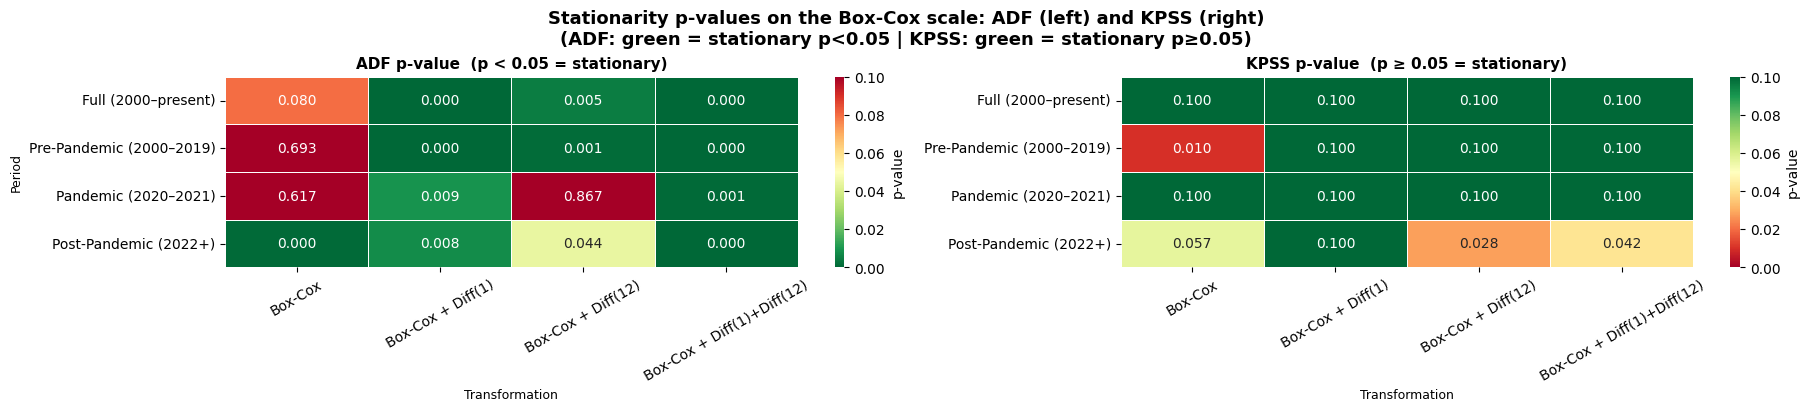

In [40]:
stationarity_label_map = dict(
    zip(period_label_order, period_series.keys())
)  # 'Full (2000–present)' → 'Full Period (2000–present)'


def boxcox_for(series, period_label):
    return boxcox_fitted[stationarity_label_map[period_label]].transform(series)


boxcox_transformations = [
    ('Box-Cox', boxcox_for),
    ('Box-Cox + Diff(1)', lambda s, p: boxcox_for(s, p).diff(1)),
    ('Box-Cox + Diff(12)', lambda s, p: boxcox_for(s, p).diff(12)),
    ('Box-Cox + Diff(1)+Diff(12)', lambda s, p: boxcox_for(s, p).diff(1).diff(12)),
]

stat_df_boxcox = stationarity_grid(stationarity_periods, boxcox_transformations)

print('=' * 100)
print('STATIONARITY TEST RESULTS — Box-Cox (Guerrero λ) variants')
print('=' * 100)
print(stat_df_boxcox[display_cols].to_string(index=False))

# side-by-side verdicts: raw vs Box-Cox
verdicts = pd.concat([stat_df, stat_df_boxcox]).pivot_table(
    index='Period', columns='Transformation', values='Joint verdict', aggfunc='first'
)
verdict_order = [
    'Raw',
    'Box-Cox',
    'Diff(1)',
    'Box-Cox + Diff(1)',
    'Diff(12)',
    'Box-Cox + Diff(12)',
    'Diff(1)+Diff(12)',
    'Box-Cox + Diff(1)+Diff(12)',
]
print()
print('JOINT VERDICT — raw vs Box-Cox')
print(verdicts.reindex(index=period_label_order, columns=verdict_order).T.to_string())

plot_stationarity_heatmaps(
    stat_df_boxcox,
    [t for t, _ in boxcox_transformations],
    period_label_order,
    'Stationarity p-values on the Box-Cox scale: ADF (left) and KPSS (right)',
)

#### Automatic Stationarity Transformation (AutoML approach)

As a last step, `AutoStationaryTransformer` (Joseph & Tackes, *Modern Time Series
Forecasting with Python* 2E, `src/transforms/target_transformations.py`) is used to let a
rule-based pipeline choose the transformations. During `fit`, it runs the same tests used
above, in this order:

1. **Trend**: `check_trend` (Mann-Kendall here). If a trend is found →
   `DetrendingTransformer(degree=1)`.
2. **Seasonality**: `check_seasonality` at m = 12. If seasonal and n > 2m →
   `DeseasonalizingTransformer` (period averages).
3. **Heteroscedasticity**: `check_heteroscedastisticity` (White). If heteroscedastic →
   `AddMTransformer` when needed to make values positive, then
   `BoxCoxTransformer(optimization='guerrero')`.

The output is then checked with the ADF + KPSS pair from the *Stationarity* section. The
fitted pipeline must also invert back to the original series (round-trip error), since
forecasts will have to be mapped back to arrival counts.

Note that the pipeline removes a **deterministic** linear trend. It does not difference
the series, so a stochastic trend (unit root) can remain in the output.

In [41]:
# Helper `AutoStationaryTransformer` from Joseph & Tackes, "Modern Time Series
# Forecasting with Python" 2E — src/transforms/target_transformations.py

auto_transformers = {}
auto_outputs = {}
auto_rows = []
for label, series in period_series.items():
    # fresh dicts every fit: the transformer mutates its parameter dicts in place
    ast = AutoStationaryTransformer(
        confidence=0.05,
        seasonal_period=SEASONAL_PERIOD,
        trend_check_params={'mann_kendall': True},
        detrender_params={'degree': 1},
        deseasonalizer_params={},
        box_cox_params={'optimization': 'guerrero'},
    )
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        transformed = ast.fit_transform(series, freq=FREQ)
    auto_transformers[label] = ast
    auto_outputs[label] = transformed

    steps = [type(tr).__name__.replace('Transformer', '') for tr in ast._pipeline]
    box_cox = [tr for tr in ast._pipeline if isinstance(tr, BoxCoxTransformer)]
    roundtrip_error = (ast.inverse_transform(transformed) - series).abs().max()
    adf_r, kpss_r, verdict = test_series(transformed, label)

    trend_flag = '✓' if ast._trend_check['trend'] else '✗'
    hetero_flag = '✓' if ast._hetero_check['heteroscedastic'] else '✗'
    auto_rows.append({
        'Period': label,
        'Pipeline': ' → '.join(steps) if steps else '(none)',
        'Trend (MK p)': f'{trend_flag} ({ast._trend_check["p_value"]:.4f})',
        'Seasonal (m=12)': '✓' if ast._seasonality_check['seasonal'] else '✗',
        'Heteroscedastic (White p)': (
            f'{hetero_flag} ({ast._hetero_check["lm_p_value"]:.4f})'
        ),
        'Box-Cox λ': f'{box_cox[0].boxcox_lambda:.3f}' if box_cox else '—',
        'ADF p': round(adf_r['p'], 4),
        'KPSS p': round(kpss_r['p'], 4),
        'Joint verdict': verdict,
        'Inverse round-trip max |error|': f'{roundtrip_error:.2e}',
    })

auto_summary = pd.DataFrame(auto_rows).set_index('Period')

print('=' * 100)
print('AUTO STATIONARY TRANSFORMER — fitted pipelines and stationarity of the output')
print('=' * 100)
print(auto_summary.T.to_string())

AUTO STATIONARY TRANSFORMER — fitted pipelines and stationarity of the output
Period                               Full Period (2000–present)      Pre-Pandemic (2000–2019)        Pandemic (2020–2021)                         Post-Pandemic (2022+)
Pipeline                        Deseasonalizing → AddM → BoxCox  Detrending → Deseasonalizing  Detrending → AddM → BoxCox  Detrending → Deseasonalizing → AddM → BoxCox
Trend (MK p)                                         ✗ (0.0758)                    ✓ (0.0000)                  ✓ (0.0060)                                    ✓ (0.0184)
Seasonal (m=12)                                               ✓                             ✓                           ✗                                             ✓
Heteroscedastic (White p)                            ✓ (0.0000)                    ✗ (0.3550)                  ✓ (0.0005)                                    ✓ (0.0122)
Box-Cox λ                                                 1.335                   

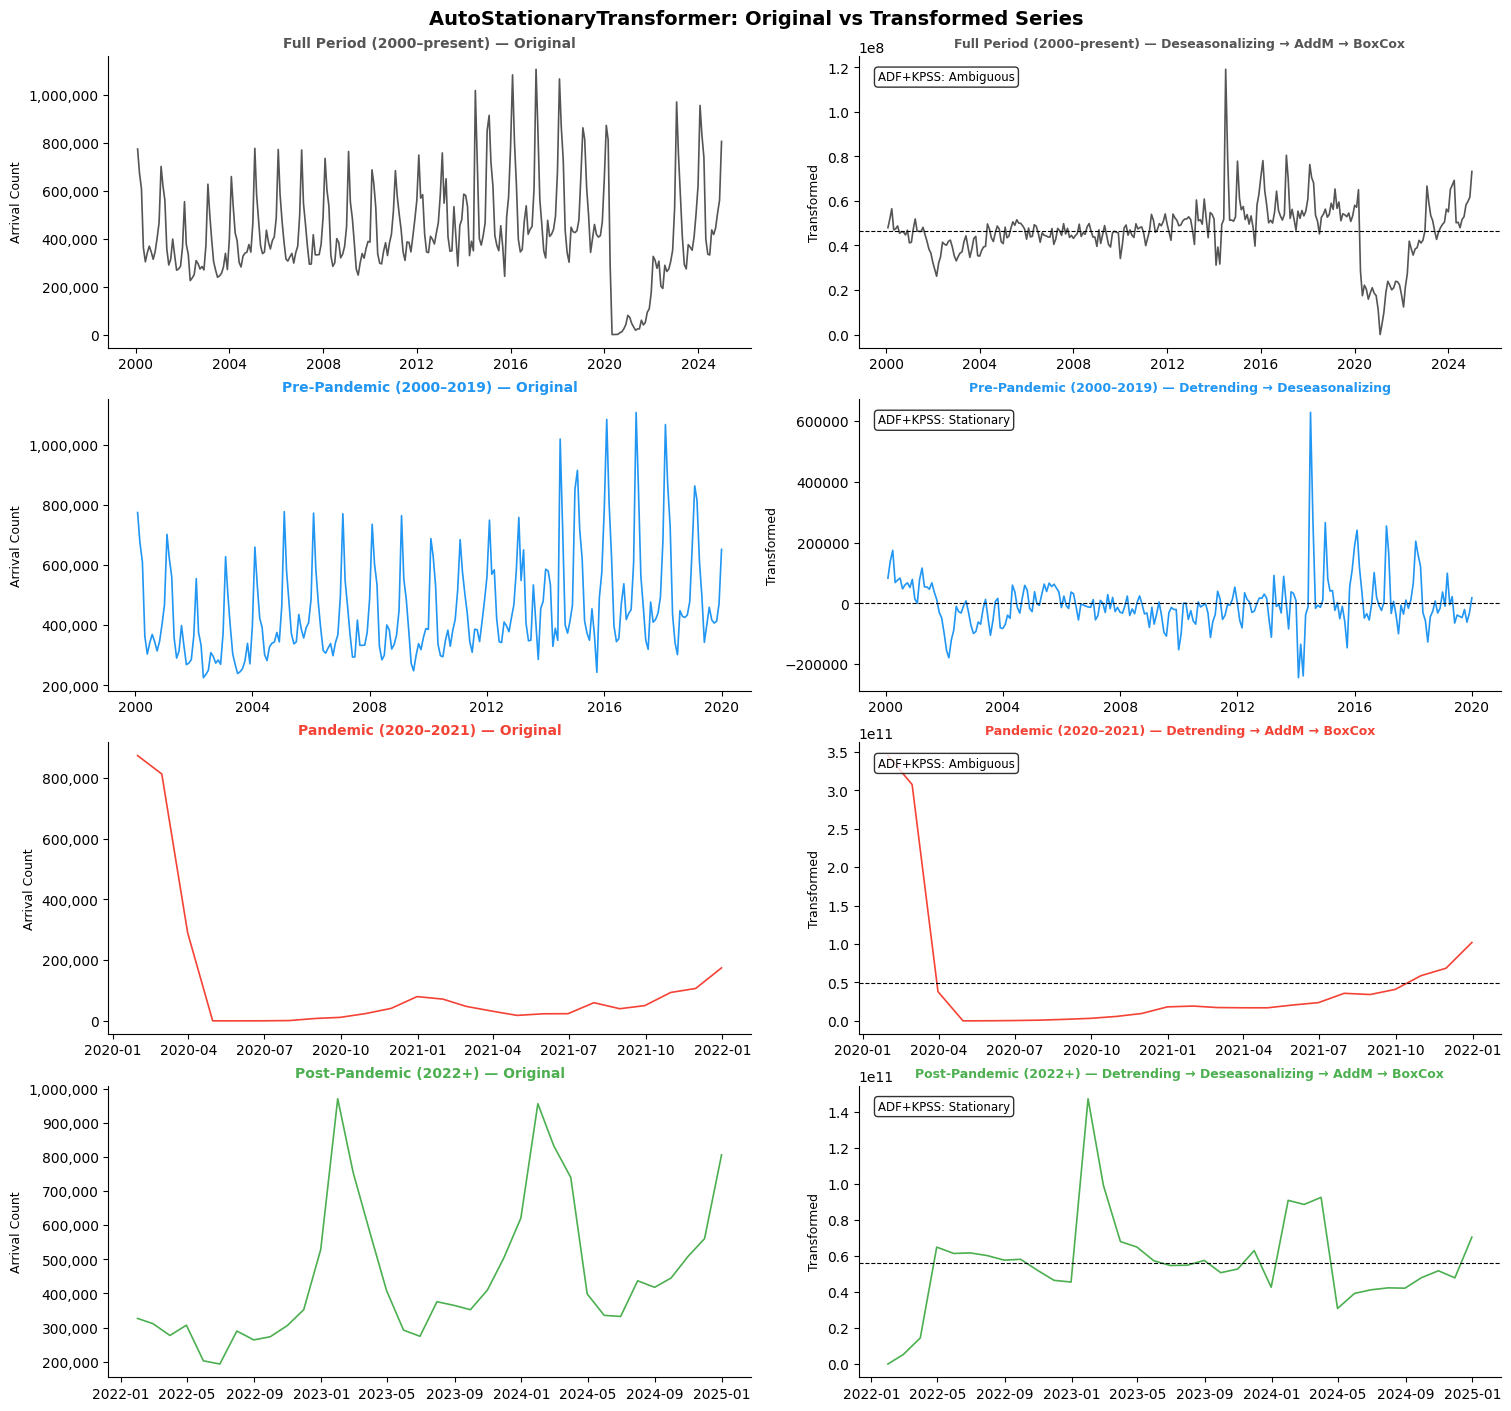

In [42]:
fig, axes = plt.subplots(4, 2, figsize=(15, 14), constrained_layout=True)
fig.suptitle(
    'AutoStationaryTransformer: Original vs Transformed Series',
    fontsize=14,
    fontweight='bold',
)

for row, (label, series) in enumerate(period_series.items()):
    color = period_series_colors[label]
    transformed = auto_outputs[label]
    pipeline = auto_summary.loc[label, 'Pipeline']

    axes[row, 0].plot(series.index, series, color=color, linewidth=1.2)
    axes[row, 0].set_title(
        f'{label} — Original', fontsize=10, fontweight='bold', color=color
    )
    axes[row, 0].set_ylabel('Arrival Count', fontsize=9)
    axes[row, 0].yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{int(x):,}')
    )

    axes[row, 1].plot(transformed.index, transformed, color=color, linewidth=1.2)
    axes[row, 1].axhline(
        transformed.mean(), color='black', linewidth=0.8, linestyle='--'
    )
    axes[row, 1].set_title(
        f'{label} — {pipeline}', fontsize=9, fontweight='bold', color=color
    )
    axes[row, 1].set_ylabel('Transformed', fontsize=9)
    axes[row, 1].annotate(
        f'ADF+KPSS: {auto_summary.loc[label, "Joint verdict"]}',
        xy=(0.03, 0.95),
        xycoords='axes fraction',
        va='top',
        fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8),
    )

    for ax in axes[row]:
        sns.despine(ax=ax)

plt.show()

#### Key Takeaways — Trend, Seasonality, Variance and Transformations

**Trend**
- Kendall's τ and Mann-Kendall detect an increasing monotonic trend in the Pre-Pandemic (Sen's slope ≈ +650 arrivals/month) and Post-Pandemic regimes. On the full 2000–present series the COVID-19 collapse masks it (MK p ≈ 0.076). Only the seasonal Mann-Kendall, which compares like months across years, still finds it (p < 0.001).
- `check_deterministic_trend` is negative in every regime (ADF `ct` does not fix what ADF `c` rejects). The trend behaves as **stochastic**, which supports differencing (d = 1) over linear detrending. The Pre-Pandemic ADF(`ct`) p ≈ 0.056 is borderline.

**Seasonality**
- `check_seasonality` confirms a significant m = 12 cycle in the Pre- and Post-Pandemic regimes, before and after linear detrending. On the full series the first significant ACF peak is at lag 6, from the two annual peaks (January and July), and m = 12 is also significant.
- The 24-month Pandemic window shows no reliable seasonality.

**Heteroscedasticity**
- The raw series is heteroscedastic by the White test in most regimes, and the annual mean–std correlation is high within each regime (0.85–0.98). Both point to a multiplicative structure.
- In the Pre-Pandemic regime, once trend and seasonality are removed, the residual variance is **not** heteroscedastic (White p ≈ 0.36). Much of the apparent variance growth comes from the seasonal amplitude scaling with the level.

**Box-Cox (Guerrero) instead of log**
- Guerrero's λ is **negative** in every regime (Pre-Pandemic λ ≈ −0.46, Post-Pandemic λ ≈ −0.59). The previously fixed log (λ = 0) was **weaker** than what the data asks for.
- In the Pre-Pandemic regime, Box-Cox removes the level–spread dependence: the annual mean–std correlation drops from 0.85 to ≈ 0.05.
- On the full 2000–present series λ ≈ 1.08 (no transformation). The COVID break dominates Guerrero's blocks, so **λ should be estimated on a stable regime** (e.g. the Pre-Pandemic training window) rather than across the structural break.
- Box-Cox does not change the differencing conclusions: Box-Cox + Diff(1) and Box-Cox + Diff(1)+Diff(12) are stationary in the Pre-Pandemic and full series, like their raw counterparts.

**AutoStationaryTransformer (automatic pipeline)**
- Pre-Pandemic: the pipeline selects `Detrending → Deseasonalizing` and skips Box-Cox, because the White test on the residual is not significant. The output is jointly stationary (ADF + KPSS).
- Full period: no trend is detected (COVID masking), so the pipeline does not detrend and the output remains *ambiguous* (ADF p ≈ 0.12). This is consistent with the stochastic-trend finding: a deterministic linear detrend is not enough across the break.
- In the pipeline, Box-Cox is applied **after** additive detrending and deseasonalizing, to residuals shifted positive by `AddMTransformer`. The resulting λ values (1.3–2.0, hitting the upper bound) are therefore **not comparable** to the Guerrero λ on the level series, and should not be taken as a statement about the variance of arrivals.
- Every fitted pipeline inverts back to the original series exactly (round-trip error < 1e-8), so it is safe to use as a target transformer for ML models.

**Implications for modelling**
- ARIMA family: Box-Cox with a Guerrero λ estimated on the training regime, then d = 1, D = 1, s = 12, i.e. SARIMA(p,1,q)(P,1,Q)[12] on the transformed scale.
- ML/DL models (XGBoost, PatchTST): `AutoStationaryTransformer` (or an explicit Box-Cox + differencing target transform) fitted **on the training window only**, then inverted on the forecasts.